# Chapter 39. Evaluation, Tuning, Interpretation & Honesty

*The runnable half of this chapter.* Every code cell below is the chapter's own code, and the words around it are the chapter's own explanation. Run the cells in order: each one uses names made by the cells before it.

Riverstone Supplies is the single worked example throughout the book, so the data here is the same data you meet in every other chapter.

Built from `manuscript/ch39-evaluation-tuning-interpretation-and-honesty.md`.

# Chapter 39. Evaluation, Tuning, Interpretation & Honesty

*Part 4 — Machine Learning & Data Science*

> **Chapter at a glance**
>
> **You will learn to:** build a confusion matrix and compute precision, recall, F1, and specificity from it by hand · draw and read ROC and precision–recall curves, and know which one to trust on imbalanced data · judge a regression model with MAE, RMSE, MAPE, and R², and know what each hides · check whether predicted probabilities are honest (calibration) and fix them when they aren't · choose a decision threshold from business costs and team capacity, not from a default of 0.5 · handle imbalanced classes with class weights and resampling, and know what they do and don't change · tune a model's settings without fooling yourself, and keep tuning and threshold choice off the test set · explain a model globally and one prediction at a time with permutation importance, SHAP, and partial dependence · check whether a model treats groups of people fairly · write a model card that says what a model is for and where it fails.
>
> **Before you start:** Chapter 35 (log loss and the base-rate benchmark, section 35.9), Chapter 36 (the lead-scoring pipeline and validation set, scikit-learn's pieces in section 36.4, cross-validation and AUC in section 36.5), Chapter 37 (logistic regression, Naive Bayes, the churn models, and tuning in section 37.11). This chapter evaluates the models you already built.
>
> **Time needed:** 16–20 hours over two to three weeks, in four sittings: (1) sections 39.1–39.3, the metrics, each worked by hand before the code (4–5 hours); (2) sections 39.4–39.7, calibration, thresholds, imbalance, and tuning (4–5 hours); (3) sections 39.8–39.10, interpretation, fairness, and model cards (4–5 hours); (4) the exercises and the project (4–5 hours).
>
> **Tools:** Python 3 with scikit-learn, plus two free libraries you install when you first need them: `imbalanced-learn` (section 39.6) and `shap` (section 39.8).
>
> **Practice data:** the lead-scoring model and validation set from Chapter 36 (2,225 leads, 146 won), and the accounts data behind Chapter 37's churn and revenue models. Every number in this chapter was calculated, and every output shown is real.

---

## Why this matters

A model's score is where most machine learning conversations start and stop: "It's 82% accurate." "AUC is 0.82." This chapter is about what those numbers hide and what a business actually needs to know:

- Chapter 36's lead model has an AUC of 0.823. **How many leads should the sales team call?** AUC can't say.
- The model predicts a 20% chance of winning a lead. **Does it win one in five of those?** That's calibration, and Naive Bayes, one of Chapter 37's algorithms, fails it badly when fitted to the leads.
- **Why did this lead score 65%?** A rep will ask, and "the model said so" is not an answer.
- **Does the model score inside-sales leads fairly?** Someone will ask that too, and the answer here is not simple.
- Predicting "no churn" for everyone is 90% accurate. **Accuracy is the wrong number** on any imbalanced problem, and most business problems are imbalanced.

The chapter's title includes *honesty* because that's the skill being taught: reporting what a model can and can't do, in units a manager understands, before anyone depends on it.

---

## In plain English

**Think of a smoke detector.**

It can fail two ways: it goes off when there's no fire (a **false positive**: annoying, you open a window), or it stays silent during a fire (a **false negative**: catastrophic). Counting the four outcomes, alarm-fire, alarm-no fire, silent-fire, silent-no fire, is a **confusion matrix**.

How sensitive should it be? Turn it up and you catch every fire but it shrieks at toast. Turn it down and it's quiet but misses a smouldering sofa. That dial is the **threshold**, and the right setting depends on how much a false alarm costs against a missed fire. That's **threshold selection by cost**. A model that reports "70% chance of fire" should be right about 70% of the time when it says that; if it says 70% and there's a fire only 10% of the time, it's **poorly calibrated**. When the alarm goes off, you'd like to know why: smoke, heat, or a low battery. That's **interpretation**. And if the detector works in the kitchen but never in the bedroom, that's a **fairness** problem someone should have tested for.

---

## 39.1 The confusion matrix

### Four numbers, then everything else

A classification model gives each lead a probability of being won. A **threshold** turns that probability into a yes-or-no decision: "predict won" if the probability is at or above the threshold, "predict lost" otherwise. Comparing the decisions with what really happened gives four counts:

| | Actually won | Actually lost |
|---|---|---|
| **Predicted won** | True positive (TP) | False positive (FP) |
| **Predicted lost** | False negative (FN) | True negative (TN) |

"Positive" means the model said *won*; "true" or "false" says whether it was right.

### Ten leads by hand

Before any real data, here are ten made-up leads, already sorted by the model's probability:

| Lead | Probability | Actually won? | At threshold 0.5 | At threshold 0.35 |
|---|---:|:---:|:---:|:---:|
| A | 0.90 | yes | TP | TP |
| B | 0.80 | yes | TP | TP |
| C | 0.70 | no | FP | FP |
| D | 0.60 | yes | TP | TP |
| E | 0.45 | no | TN | FP |
| F | 0.40 | yes | FN | TP |
| G | 0.30 | no | TN | TN |
| H | 0.20 | no | TN | TN |
| I | 0.10 | no | TN | TN |
| J | 0.05 | no | TN | TN |

Take the threshold 0.5 column first. Leads A to D are at or above 0.5, so the model says *won* for them: three were won (TP) and one, C, was lost (FP). Below 0.5, lead F was won, so it's a miss (FN), and the other five are correct *lost* predictions (TN). The counts are **TP 3, FP 1, FN 1, TN 5**, and they add up to 10.

Five numbers come from those four counts. Work each one with a pencil before reading the answer:

- **Accuracy** = (TP + TN) ÷ all = (3 + 5) ÷ 10 = **0.8**: the share of all predictions that were right.
- **Precision** = TP ÷ (TP + FP) = 3 ÷ 4 = **0.75**: of the leads the model flags, the share that are won.
- **Recall** = TP ÷ (TP + FN) = 3 ÷ 4 = **0.75**: of the leads that are won, the share the model flags. It's also called **sensitivity** or the **true positive rate**.
- **F1** = 2 × precision × recall ÷ (precision + recall) = 2 × 0.75 × 0.75 ÷ 1.5 = **0.75**: one number that is high only when both precision and recall are high. It's the **harmonic mean** of the two, which punishes a lopsided pair: precision 0.9 with recall 0.1 gives an F1 of only 0.18.
- **Specificity** = TN ÷ (TN + FP) = 5 ÷ 6 = **0.833**: of the leads that are lost, the share the model correctly leaves alone. It's also called the **true negative rate**; one minus it is the **false positive rate**, 1 ÷ 6 = 0.167.

Now lower the threshold to 0.35 (the last column). Leads E and F join the flagged group: F was won (now a TP) and E was lost (a new FP). The counts become TP 4, FP 2, FN 0, TN 4, so precision falls to 4 ÷ 6 = 0.667 and recall rises to 4 ÷ 4 = 1.0. **A lower threshold catches more wins and flags more losers with them.** That trade is the whole chapter in miniature.

scikit-learn's `confusion_matrix` counts the same four numbers. Check it on the same ten leads:

In [1]:
import numpy as np
from sklearn.metrics import confusion_matrix

toy_p = np.array([0.90, 0.80, 0.70, 0.60, 0.45, 0.40, 0.30, 0.20, 0.10, 0.05])
toy_y = np.array([1, 1, 0, 1, 0, 1, 0, 0, 0, 0])
toy_pred = (toy_p >= 0.5).astype(int)
print(toy_pred)
print(confusion_matrix(toy_y, toy_pred))
tn, fp, fn, tp = confusion_matrix(toy_y, toy_pred).ravel()
print(f"TP {tp}  FP {fp}  FN {fn}  TN {tn}")

[1 1 1 1 0 0 0 0 0 0]
[[5 1]
 [1 3]]
TP 3  FP 1  FN 1  TN 5


**How it works:**

- `toy_p` holds the ten probabilities and `toy_y` the ten outcomes, 1 for won and 0 for lost, as NumPy arrays (Chapter 18).
- `toy_p >= 0.5` compares every probability with the threshold at once and gives an array of `True`/`False`. `.astype(int)` turns `True` into 1 and `False` into 0, so `toy_pred` holds the predictions: 1 (won) for the first four leads, 0 for the rest.
- `confusion_matrix(toy_y, toy_pred)` takes the actual outcomes first and the predictions second. It prints the four counts as a 2 × 2 grid with **actual outcomes as rows and predictions as columns, in sorted order: 0 (lost) first, then 1 (won)**. So its top-left cell is TN (5), not TP. That's the opposite corner from the table above, which puts *won* first because that's how people talk about leads.
- `.ravel()` flattens the grid into one row read left to right, top to bottom: `[TN, FP, FN, TP]`. That's why the unpacking line is written `tn, fp, fn, tp = ...`, in exactly that order. Swap the names and every metric after it is wrong without any error message.

The counts match the hand count: TP 3, FP 1, FN 1, TN 5.

### The real leads

Now the real thing. Start from Chapter 36's lead model on its validation set: 2,225 leads from the first half of 2025, of which 146 were won. Open a notebook in the chapter's companion folder, `companion/ch39/`, which holds a copy of Chapter 37's helper file, `lead_data.py`:

In [2]:
import sys
import warnings

import numpy as np
import pandas as pd

sys.path.append(".")
from lead_data import LEAD_CATS, LEAD_NUMS, load_leads, make_model

warnings.filterwarnings("ignore", category=UserWarning)

train, valid, test = load_leads()
X_cols = LEAD_CATS + LEAD_NUMS
model = make_model(LEAD_CATS, LEAD_NUMS).fit(train[X_cols], train["won"])
p_valid = model.predict_proba(valid[X_cols])[:, 1]
y_valid = valid["won"].to_numpy()
print(f"{len(valid):,} validation leads, {y_valid.sum()} won ({y_valid.mean():.2%})")
print(
    f"predicted probabilities: min {p_valid.min():.3f}, median {np.median(p_valid):.3f}, "
    f"max {p_valid.max():.3f}"
)

2,225 validation leads, 146 won (6.56%)
predicted probabilities: min 0.001, median 0.037, max 0.646


**How it works:**

- `sys.path.append(".")` tells Python to look for modules in the current folder too, so `from lead_data import ...` finds `lead_data.py` next to your notebook. (Jupyter usually does this already; the line makes sure.)
- `lead_data.py` is the helper Chapter 37 wrote so that Chapter 36's work can be rebuilt in one call. `load_leads()` reads the CRM export, removes duplicate enquiries, builds Chapter 36's features, and returns three tables split by date: `train` (2023–2024), `valid` (January–June 2025), and `test` (July–September 2025). `LEAD_CATS` and `LEAD_NUMS` are the lists of category and number columns.
- `make_model(LEAD_CATS, LEAD_NUMS)` returns Chapter 36's pipeline: a `prepare` step (fill blanks, one-hot encode the categories, scale the numbers) followed by a `model` step, logistic regression. It has an optional third argument: pass a different estimator, such as `make_model(LEAD_CATS, LEAD_NUMS, GaussianNB())`, and it swaps the model while keeping the same preparation. Section 39.4 uses that.
- `warnings.filterwarnings("ignore", category=UserWarning)` hides one kind of message, `UserWarning`, which scikit-learn prints for harmless things like a category in validation that training never saw. Other warnings and every error still show.
- `.predict_proba(...)` returns two columns, P(lost) and P(won), in the order of the classes 0 and 1 (Chapter 36, section 36.4). `[:, 1]` keeps every row (`:`) of column 1, the probability of winning.
- `.to_numpy()` turns the `won` column into a plain NumPy array of 0s and 1s, so it lines up position by position with `p_valid`.

**Reading it.** 6.56% of the validation leads were won. The median lead scores 3.7%, and the highest scores only 64.6%: this model almost never thinks a lead is more likely than not to be won. Keep that in mind for the next result.

Here is a small function that builds the four counts at any threshold, run at three thresholds. Before you run it, predict: at a threshold of 0.5, how many leads will the model call *won*?

In [3]:
from sklearn.metrics import confusion_matrix


def matrix_at(threshold):
    predicted = (p_valid >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, predicted).ravel()
    return tp, fp, fn, tn


for threshold in [0.5, 0.2, 0.1]:
    tp, fp, fn, tn = matrix_at(threshold)
    print(
        f"threshold {threshold}: TP {tp:>4}  FP {fp:>5}  FN {fn:>4}  TN {tn:>5}   "
        f"accuracy {(tp + tn) / len(y_valid):.3f}"
    )

threshold 0.5: TP    4  FP     3  FN  142  TN  2076   accuracy 0.935
threshold 0.2: TP   55  FP   122  FN   91  TN  1957   accuracy 0.904
threshold 0.1: TP  100  FP   386  FN   46  TN  1693   accuracy 0.806


**How it works:**

- `matrix_at(threshold)` does in three lines what you did by hand: make the 0/1 predictions, count them against the outcomes, and unpack the counts in scikit-learn's order (`tn, fp, fn, tp`).
- It then **returns them in the book's order**, `tp, fp, fn, tn`, won first, so every later line reads like the table at the top of the section. The loop unpacks them in that same order.
- `{tp:>4}` is an f-string width (Chapter 17): `>` right-aligns the number in 4 characters, and `{fp:>5}` in 5, so the columns line up.
- Accuracy is `(tp + tn) / len(y_valid)`: correct predictions over all 2,225 leads.

**Reading it.** At the default threshold of 0.5, the model predicts "won" for **7** of 2,225 leads. It's right about 4, and misses 142 of the 146 wins. Its accuracy is 93.5%, which is *no better than* predicting "lost" for everyone (93.4%, since 2,079 ÷ 2,225 = 0.934). Accuracy tells you nothing here. The problem isn't the model: only 6.6% of leads are won, so a well-calibrated model rarely says a lead is *more likely than not* to be won. The threshold has to move.

![A two-by-two confusion matrix for the lead model at a threshold of 0.1: 100 true positives, 386 false positives, 46 false negatives, and 1,693 true negatives, with precision and recall computed in the margins](figures/fig39-1-confusion-matrix.svg)

*Figure 39.1 — The confusion matrix at a threshold of 0.1, in the book's layout (predictions as rows, won first). Precision reads across the top row; recall reads down the first column.*

### Precision, recall, F1, and the rest

From the four counts at a threshold of 0.1 (TP 100, FP 386, FN 46, TN 1,693), the same formulas as the ten-lead example:

> **precision** = TP ÷ (TP + FP) = 100 ÷ 486 = **0.206**: of the leads the model flags, one in five is won
>
> **recall** (sensitivity, true positive rate) = TP ÷ (TP + FN) = 100 ÷ 146 = **0.685**: of the leads that are won, the model flagged two thirds
>
> **F1** = 2 × precision × recall ÷ (precision + recall) = 2 × 0.206 × 0.685 ÷ 0.891 = **0.317** (0.316 from the unrounded precision and recall)
>
> **specificity** (true negative rate) = TN ÷ (TN + FP) = 1,693 ÷ 2,079 = **0.814**; its complement, the **false positive rate**, is 0.186

The same numbers in code, first from the formulas and then from scikit-learn's own functions:

In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score

tp, fp, fn, tn = matrix_at(0.1)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
specificity = tn / (tn + fp)
print(
    f"at threshold 0.1: precision {precision:.3f}   recall {recall:.3f}   "
    f"F1 {f1:.3f}   specificity {specificity:.3f}"
)
predicted = (p_valid >= 0.1).astype(int)
print(
    f"scikit-learn:     precision {precision_score(y_valid, predicted):.3f}   "
    f"recall {recall_score(y_valid, predicted):.3f}   F1 {f1_score(y_valid, predicted):.3f}"
)

at threshold 0.1: precision 0.206   recall 0.685   F1 0.316   specificity 0.814
scikit-learn:     precision 0.206   recall 0.685   F1 0.316


**How it works:**

- The first four calculations are the formulas above, typed as Python.
- `predicted` is the 0/1 prediction at 0.1 again, because scikit-learn's metric functions take labels, not probabilities.
- `precision_score`, `recall_score`, and `f1_score` each take the actual labels first and the predictions second, like `confusion_matrix`, and treat 1 as the positive class. scikit-learn has no `specificity_score`; compute it from the counts, or as the recall of class 0 with `recall_score(y_valid, predicted, pos_label=0)`.

Precision and recall pull against each other. Raise the threshold and you flag fewer leads, more of which are won (higher precision) but fewer of all the wins (lower recall). Which matters more depends entirely on the decision: a fraud alert that freezes a card wants precision; a cancer screen wants recall. F1 is a compromise for when you have no cost information; section 39.5 replaces it with something better.

### More than two classes

The same counting works when there are more than two classes, such as support tickets sorted by topic: each class gets its own precision, recall, and F1, treating "this class" as positive and "every other class" as negative. Two ways to combine them are common. Suppose the three per-class F1 scores are 0.9, 0.8, and 0.2, and the classes have 800, 150, and 50 examples (their **support**):

- **Macro F1** is the plain average: (0.9 + 0.8 + 0.2) ÷ 3 = **0.633**. Every class counts equally, so the rare class that the model handles badly drags it down.
- **Weighted F1** weights each class by its support: (0.9 × 800 + 0.8 × 150 + 0.2 × 50) ÷ 1,000 = **0.850**. The big class dominates, and the weak rare class nearly disappears.

When the rare class matters, report the macro figure, or better, the per-class table. scikit-learn's `f1_score(y, predicted, average="macro")` and `average="weighted"` compute them, and Chapter 41 uses the macro version on Riverstone's support tickets.

---

## 39.2 Curves: ROC and precision–recall

A single threshold gives a single matrix. Sweeping the threshold from high to low traces a curve, and the area under it summarizes how well the model **ranks**, without choosing a threshold at all.

- The **ROC curve** plots recall (the true positive rate) up the side against the false positive rate along the bottom. **ROC-AUC** is the area under it.
- The **precision–recall (PR) curve** plots precision up the side against recall along the bottom. **PR-AUC**, usually reported as **average precision**, summarizes it.

### Building both curves by hand

Go back to the ten leads. Start with the threshold above 0.90, so nothing is flagged, then lower it one lead at a time, and after each step write down the counts. There are 4 wins and 6 losses in total, so recall is TP ÷ 4 and the false positive rate is FP ÷ 6:

| Flag leads scoring at least | TP | FP | Recall (TPR) | False positive rate | Precision |
|---:|---:|---:|---:|---:|---:|
| 0.90 (A) | 1 | 0 | 0.25 | 0.00 | 1.00 |
| 0.80 (A–B) | 2 | 0 | 0.50 | 0.00 | 1.00 |
| 0.70 (A–C) | 2 | 1 | 0.50 | 0.17 | 0.67 |
| 0.60 (A–D) | 3 | 1 | 0.75 | 0.17 | 0.75 |
| 0.45 (A–E) | 3 | 2 | 0.75 | 0.33 | 0.60 |
| 0.40 (A–F) | 4 | 2 | 1.00 | 0.33 | 0.67 |
| 0.30 (A–G) | 4 | 3 | 1.00 | 0.50 | 0.57 |
| 0.20 (A–H) | 4 | 4 | 1.00 | 0.67 | 0.50 |
| 0.10 (A–I) | 4 | 5 | 1.00 | 0.83 | 0.44 |
| 0.05 (all) | 4 | 6 | 1.00 | 1.00 | 0.40 |

Plot the (false positive rate, recall) pairs, starting from (0, 0), and join them: that's the ROC curve. Each win moves the line **up** a step, each loss moves it **right**, so a model that puts every win above every loss goes straight up to the top-left corner and then across. Plot the (recall, precision) pairs and you have the PR curve: it starts high on the left, where only the most confident leads are flagged, and sinks toward the share of wins (4 in 10) on the right, where everything is flagged.

**ROC-AUC by counting pairs.** The area under the ROC curve has a plain meaning (Chapter 36): pick one won lead and one lost lead; AUC is the chance the won one scores higher. With 4 wins and 6 losses there are 4 × 6 = 24 pairs. Lead A beats all 6 losses, B beats all 6, D beats 5 (all but C), and F beats 4 (all but C and E). That's 6 + 6 + 5 + 4 = 21 of 24 pairs ranked correctly: **ROC-AUC = 21 ÷ 24 = 0.875**.

**Average precision by hand.** Walk down the list and, each time you reach a win, write down the precision at that point: at A it's 1 ÷ 1, at B 2 ÷ 2, at D 3 ÷ 4, and at F 4 ÷ 6. Average precision is the average of those four numbers: (1 + 1 + 0.75 + 0.667) ÷ 4 = **0.854**. A model that puts every win at the top scores 1.

**What "random" scores.** A model that orders leads at random puts wins and losses in the same proportions all the way down the list, so its precision at every depth is about the share of wins, the **base rate**. Its average precision is therefore about the base rate, 0.4 for the ten leads. A random model's ROC-AUC is 0.5 whatever the base rate: half the pairs come out right by luck.

scikit-learn agrees with both hand results:

In [5]:
from sklearn.metrics import average_precision_score, roc_auc_score

print(f"ROC-AUC {roc_auc_score(toy_y, toy_p):.3f}")
print(f"average precision {average_precision_score(toy_y, toy_p):.3f}")

ROC-AUC 0.875
average precision 0.854


Both functions take the actual labels and the **probabilities** (not 0/1 predictions), because they sweep every threshold themselves.

### The real curves

On the 2,225 validation leads, `roc_curve` and `precision_recall_curve` do the sweep, and the two area functions summarize it:

In [6]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, roc_thresholds = roc_curve(y_valid, p_valid)
prec, rec, pr_thresholds = precision_recall_curve(y_valid, p_valid)
print(
    f"ROC-AUC {roc_auc_score(y_valid, p_valid):.3f}   "
    f"PR-AUC (average precision) {average_precision_score(y_valid, p_valid):.3f}   "
    f"base rate {y_valid.mean():.3f}"
)
print(f"the ROC curve has {len(fpr)} points; the PR curve has {len(prec)}")
random_pr = y_valid.mean()
print(f"a random model would score PR-AUC {random_pr:.3f} and ROC-AUC 0.500")

ROC-AUC 0.823   PR-AUC (average precision) 0.302   base rate 0.066
the ROC curve has 240 points; the PR curve has 2226
a random model would score PR-AUC 0.066 and ROC-AUC 0.500


**How it works:**

- `roc_curve` returns three arrays of equal length: the false positive rate and the true positive rate at each threshold, and the thresholds themselves. Unpacking them into `fpr, tpr, roc_thresholds` keeps all three.
- `precision_recall_curve` returns **precision first, then recall**, then the thresholds. The order is easy to swap by mistake; the names `prec, rec` follow it.
- The two curves have different numbers of points because `roc_curve` has a setting, `drop_intermediate=True` by default, that drops points which don't change the curve's shape (a run of losses in a row is one straight line). The PR curve keeps a point for every distinct score, plus one at the end.
- `random_pr` is the base rate, from the argument above.

Seeing the curves helps. A short matplotlib cell draws them (Chapter 18 introduced `plt.subplots`):

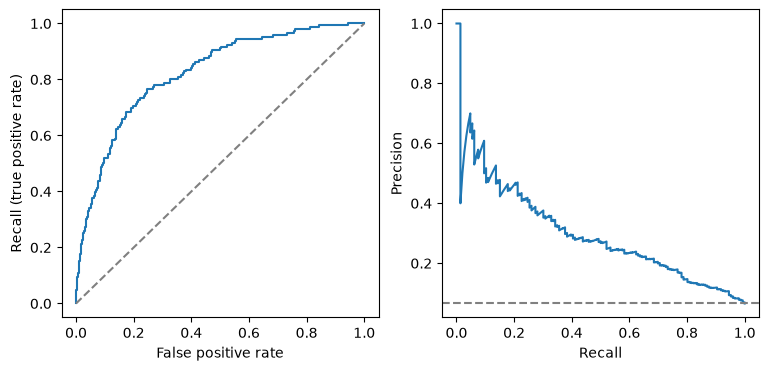

In [7]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(9, 4))
left.plot(fpr, tpr)
left.plot([0, 1], [0, 1], linestyle="--", color="grey")
left.set_xlabel("False positive rate")
left.set_ylabel("Recall (true positive rate)")
right.plot(rec, prec)
right.axhline(y_valid.mean(), linestyle="--", color="grey")
right.set_xlabel("Recall")
right.set_ylabel("Precision")
plt.show()

**How it works:**

- `plt.subplots(1, 2, figsize=(9, 4))` makes one figure with **1 row and 2 columns** of plots; the two axes come back as a pair, unpacked into `left` and `right`.
- `left.plot(fpr, tpr)` draws the ROC curve. `left.plot([0, 1], [0, 1], ...)` adds the diagonal from (0, 0) to (1, 1), where a random model lies; `linestyle="--"` makes it dashed and `color="grey"` keeps it quiet.
- `right.plot(rec, prec)` draws the PR curve with recall along the bottom. `right.axhline(y_valid.mean(), ...)` draws a horizontal line (the *h* in `axhline`) across the whole plot at the base rate, the random model's precision.
- `plt.show()` displays the figure under the cell. Figure 39.2 is the same two curves, redrawn for print.

![Two panels: the ROC curve for the lead model bowing toward the top left with AUC 0.823 and a diagonal chance line, and the precision–recall curve falling from high precision at low recall to the base rate of 0.066, with average precision 0.302](figures/fig39-2-roc-pr.svg)

*Figure 39.2 — ROC (left) and precision–recall (right) curves for the lead model. The ROC curve looks impressive; the PR curve shows what the sales team will experience: precision falls fast as they call further down the list.*

**Reading it.** ROC-AUC is 0.823 and looks good. PR-AUC is 0.302, which looks poor, and both are correct. The difference is the base rate. A random model scores 0.5 on ROC-AUC regardless of imbalance, but only 0.066 on PR-AUC here (the base rate). The lead model's PR-AUC is 4.6 times a random model's, which is a real achievement, and it still means that a rep working the list will hear "no" most of the time.

**Which to report.** On imbalanced problems, **PR-AUC is the more honest summary**, because it's built from precision, the number the person acting on the model feels. ROC-AUC is fine for comparing models and for balanced problems. Report both, and say what the base rate is.

### The list, not the curve

The most useful evaluation for a call list isn't a curve at all. It's *"if we call the top N, how many do we win?"* That's a **top-N table**:

In [8]:
order = np.argsort(-p_valid)
for k in [50, 100, 200, 400]:
    top = order[:k]
    print(
        f"top {k:>3} leads by score: {y_valid[top].sum():>3} won "
        f"({y_valid[top].mean():.1%} of them; "
        f"{y_valid[top].sum() / y_valid.sum():.1%} of all wins)"
    )

top  50 leads by score:  22 won (44.0% of them; 15.1% of all wins)
top 100 leads by score:  38 won (38.0% of them; 26.0% of all wins)
top 200 leads by score:  59 won (29.5% of them; 40.4% of all wins)
top 400 leads by score:  92 won (23.0% of them; 63.0% of all wins)


**How it works:**

- `np.argsort(p)` returns the *positions* of the values in ascending order. The minus sign in `np.argsort(-p_valid)` sorts the negated scores ascending, which is the real scores **descending**: `order[0]` is the position of the highest-scoring lead.
- `order[:k]` keeps the first `k` positions, and `y_valid[top]` picks those leads' outcomes. `.sum()` counts the wins among them and `.mean()` is their win rate.
- The last number divides by all 146 wins: the share of every win that the top `k` contains.

**Reading it.** The top 50 leads by score are won 44% of the time, nearly seven times the 6.6% base rate. The top 400 (18% of leads) contain 63% of all the wins. This table is what to show a sales head, because it answers the question they'll ask, and it leads straight into section 39.5, which decides how far down the list to go.

---

## 39.3 Regression metrics

For models that predict a number, the confusion matrix has no equivalent; the errors are amounts. Four measures are common, and a small example shows what each one does.

### Four accounts by hand

A model predicts four accounts' revenue for next year. Amounts are in ₹ thousands; the **error** is actual minus predicted:

| Account | Actual | Predicted | Error | Error² | Error as % of actual |
|---|---:|---:|---:|---:|---:|
| 1 | 100 | 110 | −10 | 100 | 10% |
| 2 | 200 | 180 | 20 | 400 | 10% |
| 3 | 50 | 70 | −20 | 400 | 40% |
| 4 | 1,000 | 700 | 300 | 90,000 | 30% |

- **MAE** (mean absolute error): the average size of a miss, ignoring its sign. (10 + 20 + 20 + 300) ÷ 4 = **87.5**, so ₹87,500. In the same units as the target, so it's the easiest to say out loud.
- **RMSE** (root mean squared error): square each error, average, then take the square root. (100 + 400 + 400 + 90,000) ÷ 4 = 22,725, and √22,725 = **150.7**, so about ₹1,50,700. Squaring makes big misses count far more: account 4's miss is 99% of the squared total, and it pushes RMSE to 1.7 times the MAE.
- **MAPE** (mean absolute percentage error): the average miss as a share of the actual value. (10% + 10% + 40% + 30%) ÷ 4 = **22.5%**. The small account 3, missed by only 20, contributes the biggest percentage.
- **R²** (Chapter 37): 1 − (sum of squared errors ÷ sum of squared distances from the mean). The mean actual is 337.5, and the squared distances from it add up to 596,875, so R² = 1 − 90,900 ÷ 596,875 = **0.848**: the model explains about 85% of the spread in revenue.

scikit-learn has a function for each:

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)

toy_actual = np.array([100, 200, 50, 1000])
toy_predicted = np.array([110, 180, 70, 700])
print(f"MAE  {mean_absolute_error(toy_actual, toy_predicted):.1f}")
print(f"RMSE {root_mean_squared_error(toy_actual, toy_predicted):.1f}")
print(f"MAPE {mean_absolute_percentage_error(toy_actual, toy_predicted):.1%}")
print(f"R²   {r2_score(toy_actual, toy_predicted):.3f}")

MAE  87.5
RMSE 150.7
MAPE 22.5%
R²   0.848


`toy_actual` and `toy_predicted` are the table's two columns as NumPy arrays (`np.array`). `mean_absolute_error`, `root_mean_squared_error`, `mean_absolute_percentage_error`, and `r2_score` all come from `sklearn.metrics`, and each takes the actual values first and the predictions second. `mean_absolute_percentage_error` returns a fraction (0.225), which the `:.1%` format prints as a percentage. All four match the hand results.

**MAPE is lopsided.** An actual of 100 with a forecast of 150 is a 50% error; an actual of 150 with a forecast of 100 is a 33% error, the same 50-unit miss. For positive actuals, a forecast that's too low can be off by at most 100% (forecasting zero), while one that's too high has no limit. So when you choose between models by MAPE, the one that forecasts low tends to win. MAPE also breaks near zero: a ₹100 miss on a ₹200 account is 50%.

**WAPE** (weighted absolute percentage error) fixes both problems: the sum of the absolute errors divided by the sum of the actuals. For the four accounts, 350 ÷ 1,350 = 25.9%. Big accounts count in proportion to their size, and a tiny account can't blow it up. Chapter 40 uses it for demand forecasts.

### Riverstone's revenue model

Now a real model: a simplified version of Chapter 37's revenue model, predicting each account's 2025 revenue from its 2024 revenue alone. (Chapter 37's full model, with all its features, had an MAE of ₹87,471; this one-feature version will do a little worse.) The first cell fits it:

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

accounts = pd.read_csv("../accounts/accounts.csv")
stayed = accounts[accounts["churned_2025"] == 0].copy()
stayed["log_revenue_2024"] = np.log(stayed["revenue_2024"])
stayed["log_revenue_2025"] = np.log(stayed["revenue_2025"])
reg_train, reg_test = train_test_split(stayed, test_size=0.25, random_state=37)
reg = LinearRegression().fit(
    reg_train[["log_revenue_2024"]], reg_train["log_revenue_2025"]
)
pred_rupees = np.exp(reg.predict(reg_test[["log_revenue_2024"]]))
actual = reg_test["revenue_2025"]
print(f"{len(reg_train):,} accounts to fit, {len(reg_test):,} to test")
print(
    pd.DataFrame({"actual": actual.to_numpy(), "predicted": pred_rupees})
    .head(3)
    .round()
    .astype(int)
    .to_string(index=False)
)

3,387 accounts to fit, 1,129 to test
 actual  predicted
  71100      65555
 788900    1415926
  28800      60997


**How it works:**

- `accounts.csv` is Chapter 37's accounts table. `stayed` keeps only accounts that didn't churn (`churned_2025 == 0`), because an account that left has no 2025 revenue to predict. `.copy()` makes it a separate table, so adding columns doesn't touch `accounts`.
- `np.log` takes the natural logarithm. Revenue is skewed, a few huge accounts and many small ones, and on the log scale the relationship between two years is close to a straight line (Chapter 37 fitted it the same way).
- `train_test_split(stayed, test_size=0.25, random_state=37)` holds back a random 25% of accounts for testing; `random_state=37` makes the split the same every time, the seed Chapter 37 used.
- `reg.predict(...)` gives predictions of **log** revenue. `np.exp` undoes the logarithm, turning them back into rupees, so every metric below is in rupees, the unit a manager cares about.
- The table shows the first three test accounts, rounded to whole rupees with `.round().astype(int)`. The second is a warning of what's coming: actual ₹7,88,900, predicted ₹14,15,926.

The second cell computes the four measures and looks at the biggest misses:

In [11]:
print(f"MAE   ₹{mean_absolute_error(actual, pred_rupees):>12,.0f}")
print(f"RMSE  ₹{root_mean_squared_error(actual, pred_rupees):>12,.0f}")
print(f"MAPE   {mean_absolute_percentage_error(actual, pred_rupees):>12.1%}")
print(
    f"R²     {r2_score(actual, pred_rupees):>12.3f}   (R² on log scale "
    f"{r2_score(reg_test['log_revenue_2025'], np.log(pred_rupees)):.3f})"
)
errors = (actual - pred_rupees).abs().sort_values(ascending=False)
print(
    f"largest single error ₹{errors.iloc[0]:,.0f}; the 10 largest errors are "
    f"{errors.iloc[:10].sum() / errors.sum():.1%} of the total absolute error"
)

MAE   ₹      92,933
RMSE  ₹     232,567
MAPE          19.2%
R²            0.927   (R² on log scale 0.955)
largest single error ₹3,697,812; the 10 largest errors are 15.2% of the total absolute error


**How it works:**

- The first four lines are the same functions as the four-account example. `:>12,.0f` right-aligns in 12 characters, with a comma separator and no decimals. Python's comma groups digits in thousands, so it prints ₹232,567 where this book writes ₹2,32,567 (section 4.9 shows both styles).
- The R² line computes it twice: on rupees, and on the log scale the model was fitted on.
- `errors` is the absolute miss for each test account, sorted with `ascending=False` so the biggest comes first. `.iloc[0]` is the first (largest), and `.iloc[:10].sum() / errors.sum()` is the ten largest misses' share of all the miss.

**Reading it.**

- **MAE** is ₹92,933: "our forecast is typically off by about ₹93,000 per account". It's the right number to quote to a manager.
- **RMSE** is ₹2,32,567, two and a half times the MAE, because squaring makes big misses dominate: the ten largest errors are 15% of the total error, and one account is off by about ₹37 lakh. RMSE is the right measure when large errors are disproportionately costly; otherwise it's dragged around by outliers.
- **MAPE** is 19.2%. Managers like it because it's scale-free; remember that it favours low forecasts.
- **R²** is 0.927 in rupees and 0.955 on the log scale. The same model, two R² values: R² depends on what scale you measure it on, and comparing R² between models fitted to different targets is meaningless.

> **Watch out: the metric must match the loss.** A model trained on log revenue minimizes percentage-type errors, so it does well on MAPE and worse on RMSE in rupees, where the largest accounts dominate. If the business cares about total rupees, train on rupees (or weight by size). Decide what error costs the business before you decide what to optimize.

---

## 39.4 Calibration: are the probabilities honest?

A model can rank well and still lie about probabilities. **Calibration** asks: among leads the model gave a 20% chance, were about 20% won? The check is a **reliability curve**: put the leads into bins by predicted probability, and plot the actual win rate in each bin against the average prediction in it. A perfectly calibrated model lies on the diagonal, where predicted equals actual.

### Two summary numbers, by hand

Two numbers summarize how honest the probabilities are, both "lower is better". Take three leads with predictions 0.8, 0.1, and 0.3, of which the first and third were won (outcomes 1, 0, 1):

- The **Brier score** is the mean squared difference between prediction and outcome: ((1 − 0.8)² + (0 − 0.1)² + (1 − 0.3)²) ÷ 3 = (0.04 + 0.01 + 0.49) ÷ 3 = **0.18**. A perfect model scores 0. The third lead, a win given only 30%, contributes most.
- **Log loss** (Chapter 35, section 35.9) averages −ln(the probability the model gave to what actually happened): (−ln 0.8 − ln 0.9 − ln 0.3) ÷ 3 = (0.223 + 0.105 + 1.204) ÷ 3 = **0.511**. It punishes confident mistakes far harder than Brier does.

Both need a benchmark. A model that knows nothing predicts the base rate *p* for every lead. Its Brier score works out to *p* × (1 − *p*): for the leads' base rate of 0.0656, that's 0.0656 × 0.9344 = **0.0613**. A real model has to beat that to be telling you anything about individual leads.

### Checking the lead model

`calibration_curve` makes the reliability table. Start with the logistic regression model you already have:

In [12]:
from sklearn.calibration import calibration_curve

frac_won, mean_pred = calibration_curve(y_valid, p_valid, n_bins=10, strategy="quantile")
print(
    pd.DataFrame({"mean predicted": mean_pred, "actual win rate": frac_won})
    .round(3)
    .to_string(index=False)
)

 mean predicted  actual win rate
          0.005            0.004
          0.010            0.009
          0.015            0.018
          0.021            0.005
          0.031            0.027
          0.044            0.059
          0.061            0.027
          0.088            0.076
          0.138            0.144
          0.278            0.287


**How it works:**

- `calibration_curve(y_valid, p_valid, ...)` takes the outcomes and the probabilities. It returns **the actual rate first, then the mean prediction**, one value per bin, which is the opposite of how you'd plot them (prediction along the bottom). The names `frac_won, mean_pred` follow its order.
- `n_bins=10` asks for ten bins.
- `strategy="quantile"` makes bins with **equal numbers of leads**: here about 222 each, the lowest-scoring tenth, the next tenth, and so on. The default, `"uniform"`, makes bins of equal *width* (0–0.1, 0.1–0.2, …), which on these skewed probabilities would put almost every lead in the first bin and leave the top bins nearly empty.
- The `DataFrame` just puts the two arrays side by side for printing.

**Reading it.** Each row is a tenth of the leads. The lowest tenth is predicted to win 0.5% of the time and actually wins 0.4%; the top tenth is predicted 27.8% and wins 28.7%. The middle bins wobble (the seventh predicts 6.1% and wins 2.7%, the sixth predicts 4.4% and wins 5.9%), which is what an average of about 15 wins per bin looks like. There's no steady drift away from the diagonal: this model's probabilities are honest.

The two summary numbers for the same model:

In [13]:
from sklearn.metrics import brier_score_loss, log_loss

print(f"log loss {log_loss(y_valid, p_valid):.4f}")
print(f"Brier    {brier_score_loss(y_valid, p_valid):.4f}   (base rate for everyone: 0.0613)")

log loss 0.1948
Brier    0.0531   (base rate for everyone: 0.0613)


`log_loss` and `brier_score_loss` both take the outcomes and the probabilities. The Brier score, 0.0531, beats the know-nothing 0.0613 by a modest margin, which is typical for a problem where most leads look alike.

### A model that fails the check

Now fit two of Chapter 37's other algorithms to the same leads: Naive Bayes (section 37.5) and gradient boosting (section 37.8). Both go through `make_model`, with the estimator passed as its third argument:

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(lambda X: X.toarray() if hasattr(X, "toarray") else X)
nb = make_model(LEAD_CATS, LEAD_NUMS, GaussianNB())
nb.steps.insert(1, ("dense", to_dense))
boost = make_model(LEAD_CATS, LEAD_NUMS, HistGradientBoostingClassifier(random_state=39))
print([name for name, step in nb.steps])

['prepare', 'dense', 'model']


**How it works:**

- `GaussianNB` can't read the compressed (sparse) table that one-hot encoding produces when there are many categories, as there are here with the lead cities. (On Chapter 37's accounts the table came out as an ordinary one, so the problem didn't arise there.)
- `FunctionTransformer(...)` turns any function into a pipeline step. The function here is a `lambda` (Chapter 18), a one-line function without a name: if the table `X` has a `toarray` method (only compressed tables do), it returns `X.toarray()`, the ordinary version; otherwise it returns `X` unchanged. The step is called `to_dense`.
- `nb.steps` is the pipeline's list of `(name, step)` pairs. `.insert(1, ("dense", to_dense))` puts the new step at position 1, second in the list: after `prepare` (position 0) and before `model`. The printed names confirm the order.
- `HistGradientBoostingClassifier(random_state=39)` is Chapter 37's boosting model with its default settings; the seed makes it repeatable.

Now score all three the same way. Predict before you run it: which model will have the worst log loss?

In [15]:
probs = {
    "logistic regression": p_valid,
    "Naive Bayes": nb.fit(train[X_cols], train["won"]).predict_proba(valid[X_cols])[:, 1],
    "gradient boosting": boost.fit(train[X_cols], train["won"]).predict_proba(
        valid[X_cols]
    )[:, 1],
}
curves = {}
for name, p in probs.items():
    frac_won_m, mean_pred_m = calibration_curve(y_valid, p, n_bins=10, strategy="quantile")
    curves[name] = (mean_pred_m, frac_won_m)
    print(
        f"{name:<20} ROC-AUC {roc_auc_score(y_valid, p):.3f}   log loss {log_loss(y_valid, p):.4f}"
        f"   Brier {brier_score_loss(y_valid, p):.4f}   mean prediction {p.mean():.3f}"
    )
print(f"actual win rate {y_valid.mean():.3f}")
print("\nNaive Bayes, by tenth of predicted probability:")
print(
    pd.DataFrame(
        {"mean predicted": curves["Naive Bayes"][0], "actual win rate": curves["Naive Bayes"][1]}
    )
    .round(3)
    .to_string(index=False)
)

logistic regression  ROC-AUC 0.823   log loss 0.1948   Brier 0.0531   mean prediction 0.069
Naive Bayes          ROC-AUC 0.806   log loss 0.4830   Brier 0.1243   mean prediction 0.180
gradient boosting    ROC-AUC 0.781   log loss 0.2096   Brier 0.0562   mean prediction 0.064
actual win rate 0.066

Naive Bayes, by tenth of predicted probability:
 mean predicted  actual win rate
          0.000            0.009
          0.000            0.014
          0.000            0.013
          0.000            0.027
          0.002            0.018
          0.010            0.032
          0.045            0.050
          0.192            0.076
          0.610            0.149
          0.939            0.269


**How it works:**

- `probs` is a dictionary from each model's name to its validation probabilities. Each entry fits the model on the training leads and keeps column 1 of `predict_proba`, the same pattern as the first model.
- The loop runs the reliability table and the three scores for each model. `curves[name]` keeps the (mean prediction, actual rate) pair in plotting order, for the figure below.
- The last lines print Naive Bayes's reliability table, as for logistic regression above.

A plot shows all three at once. Markers make each model's bins visible:

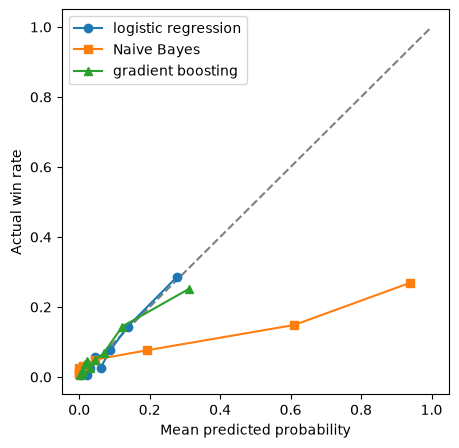

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
for name, marker in zip(curves, ["o", "s", "^"]):
    ax.plot(curves[name][0], curves[name][1], marker=marker, label=name)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual win rate")
ax.legend()
plt.show()

**How it works:** the dashed diagonal is perfect calibration. `zip(curves, ["o", "s", "^"])` pairs each model's name with a marker shape (circle, square, triangle), so the lines can be told apart without colour. `label=name` names each line, and `ax.legend()` draws the key.

![Two panels of reliability curves against the diagonal, with circles for logistic regression, squares for Naive Bayes and triangles for gradient boosting. Left, the full range: logistic regression and gradient boosting close to the line, Naive Bayes far below it at high predictions, its top tenth predicting 0.94 against an actual 0.27. Right, the 0 to 0.3 corner enlarged, where logistic regression and boosting track the diagonal](figures/fig39-3-calibration.svg)

*Figure 39.3 — Reliability curves for three models. Logistic regression and gradient boosting are honest; Naive Bayes is confidently wrong in both directions. The right panel enlarges the corner where most leads sit; each model has its own marker shape.*

**Reading it.** Logistic regression and gradient boosting are well calibrated: their average prediction (6.9% and 6.4%) matches the actual win rate (6.6%), and their bins sit near the diagonal. Naive Bayes is a different story. Its average prediction is **18%**, nearly three times the real rate, and its top tenth predicts a **94%** chance of winning for leads that are won **27%** of the time. It ranks reasonably (ROC-AUC 0.806) and its probabilities are fiction. This is the overconfidence Chapter 37 warned about when it fitted Naive Bayes, and it matters the moment someone uses the number: a rep told "94%" who wins one in four will stop trusting every model.

### Fixing calibration

`CalibratedClassifierCV` wraps a model and learns a correction from its score to a real probability. It has two methods:

- **Platt scaling** (`method="sigmoid"`) fits a logistic curve from score to probability: just two numbers, a slope and an intercept.
- **Isotonic regression** (`method="isotonic"`) fits any rising step function. It can bend to any shape, and so needs more data: a common rule of thumb is sigmoid below about a thousand positive examples, isotonic above.

In [17]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_nb = CalibratedClassifierCV(nb, method="isotonic", cv=5).fit(
    train[X_cols], train["won"]
)
p_nb_cal = calibrated_nb.predict_proba(valid[X_cols])[:, 1]
print(
    f"Naive Bayes, isotonic calibration: log loss {log_loss(y_valid, p_nb_cal):.4f}   "
    f"Brier {brier_score_loss(y_valid, p_nb_cal):.4f}  "
    f" ROC-AUC {roc_auc_score(y_valid, p_nb_cal):.3f}"
)
print(
    f"(before calibration: ROC-AUC {roc_auc_score(y_valid, probs['Naive Bayes']):.3f})"
)

Naive Bayes, isotonic calibration: log loss 0.2022   Brier 0.0544   ROC-AUC 0.802
(before calibration: ROC-AUC 0.806)


**How it works:**

- `CalibratedClassifierCV(nb, ...)` takes the unfitted pipeline and fits it itself.
- `cv=5` splits the training leads five ways, as in Chapter 36's cross-validation. Each time, Naive Bayes is fitted on four parts and the calibrator learns its correction on the fifth, so the correction never comes from rows the model trained on. That gives five (model, calibrator) pairs, and at prediction time their five probabilities are averaged.
- The training leads have 576 wins, fewer than the rule of thumb's thousand, so isotonic is a risk here; exercise 11 compares it with sigmoid.

**Reading it.** After isotonic calibration, Naive Bayes's log loss drops from 0.483 to 0.202 and its Brier score from 0.124 to 0.054, close to logistic regression's. Its ranking barely changes (ROC-AUC 0.806 to 0.802), because calibration reshapes the scores without reordering them much. **Calibration fixes the numbers, not the ranking.**

> **When calibration matters:** whenever the probability is used as a number: expected value calculations (the next section), thresholds by cost, combining models, showing a percentage to a person. When only the order matters, such as a call list, it doesn't.

---

## 39.5 Choosing the threshold by business cost

### The two numbers you need

A threshold is a business decision disguised as a model setting. To set it, you need what a false positive and a true positive are worth. For lead scoring, working a lead properly costs time, and winning one earns margin:

In [18]:
# ₹ to work a lead properly: calls, a quote, samples (about 2 rep-hours)
WORK_COST = 1500
new_accounts = accounts[accounts["tenure_months"] <= 12]
FIRST_YEAR_REVENUE = new_accounts["revenue_2024"].median()
MARGIN = 0.15
WIN_VALUE = FIRST_YEAR_REVENUE * MARGIN
print(
    f"{len(new_accounts)} accounts in their first "
    f"year: median revenue ₹{FIRST_YEAR_REVENUE:,.0f}"
)
print(f"value of a won lead at {MARGIN:.0%} margin: ₹{WIN_VALUE:,.0f}")
print(f"break-even win probability: {WORK_COST / WIN_VALUE:.4f}")

878 accounts in their first year: median revenue ₹201,700
value of a won lead at 15% margin: ₹30,255
break-even win probability: 0.0496


**How it works:** the cost to work a lead, ₹1,500, covers calls, a quote, and samples, about two hours of a rep's time; change it to your own number. The value of a win is the median first-year revenue of Riverstone's newer accounts (₹2,01,700, from the accounts data: accounts with 12 months' tenure or less) times a 15% gross margin: ₹30,255. Both are stated assumptions, written in capitals as constants; the point of naming them is that the sales head can argue with them and re-run the analysis.

**Break-even.** Working a lead pays off when *p* × ₹30,255 > ₹1,500, so *p* > 1,500 ÷ 30,255 = **0.0496**. Any lead with a calibrated probability above about 5% is worth working. That number came from costs, not from the model, and it's nowhere near 0.5.

### The profit curve

Expected profit at a threshold is simple arithmetic: each won lead that's worked earns ₹30,255, and every worked lead costs ₹1,500. A small function works it out at any threshold:

In [19]:
def profit_at(threshold, p=p_valid, y=y_valid):
    called = p >= threshold
    return (
        WIN_VALUE * y[called].sum() - WORK_COST * called.sum(),
        called.sum(),
        y[called].sum(),
    )


print("threshold   worked   wins     profit")
for threshold in [0.0, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.50]:
    profit, worked, wins = profit_at(threshold)
    print(f"{threshold:>9.2f}   {worked:>6}   {wins:>4}   ₹{profit:>10,.0f}")

threshold   worked   wins     profit
     0.00     2225    146   ₹ 1,079,730
     0.02     1476    138   ₹ 1,961,190
     0.03     1239    135   ₹ 2,225,925
     0.05      904    121   ₹ 2,304,855
     0.07      684    114   ₹ 2,423,070
     0.10      486    100   ₹ 2,296,500
     0.15      291     76   ₹ 1,862,880
     0.20      177     55   ₹ 1,398,525
     0.50        7      4   ₹   110,520


**How it works:**

- `profit_at` marks the leads at or above the threshold as `called` (an array of `True`/`False`). `y[called].sum()` counts the wins among them and `called.sum()` counts them all, because `True` counts as 1. It returns three things: the profit, the number worked, and the wins.
- `p=p_valid, y=y_valid` are **default arguments**: if you call `profit_at(0.05)`, it uses the validation probabilities and outcomes; exercise 13 passes the test set's instead.

Nine thresholds are a sketch. To find the best one, try 501 of them:

In [20]:
grid = np.linspace(0.0, 0.5, 501)
profits = np.array([profit_at(t)[0] for t in grid])
best = grid[profits.argmax()]
print(f"best threshold on the grid: {best:.3f}   profit ₹{profits.max():,.0f}")
print(f"working every lead: ₹{profit_at(0.0)[0]:,.0f}   working none: ₹0")

best threshold on the grid: 0.077   profit ₹2,448,060
working every lead: ₹1,079,730   working none: ₹0


**How it works:**

- `np.linspace(0.0, 0.5, 501)` makes 501 evenly spaced thresholds from 0 to 0.5, one every 0.001.
- The list comprehension calls `profit_at` once per threshold and keeps element `[0]`, the profit; `np.array` makes the 501 profits an array.
- `profits.argmax()` is the *position* of the largest profit, and `grid[...]` turns it into the threshold at that position.

A line plot of `profits` against `grid` is the profit curve:

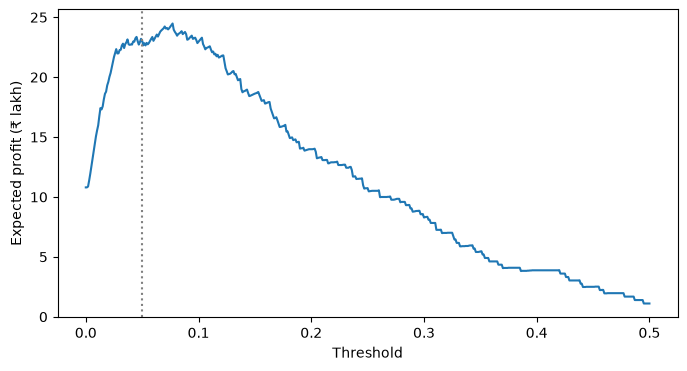

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, profits / 1e5)
ax.axvline(WORK_COST / WIN_VALUE, linestyle=":", color="grey")
ax.set_xlabel("Threshold")
ax.set_ylabel("Expected profit (₹ lakh)")
plt.show()

**How it works:** dividing by `1e5` (100,000) shows profit in lakhs. `ax.axvline(...)` draws a vertical line (the *v*) at the break-even probability, the partner of `axhline` in section 39.2.

![Expected profit on the validation leads against the threshold from 0 to 0.5, rising from 10.8 lakh rupees at threshold 0 to a broad, jagged peak of about 24.5 lakh near 0.077, then falling to near zero, with the break-even threshold of 0.05 marked](figures/fig39-4-profit-curve.svg)

*Figure 39.4 — Profit against threshold. Working every lead is profitable but wasteful; the peak is broad, so anything between 0.05 and 0.10 is close to best; above 0.15 the team is leaving money on the table.*

**Reading it.** Working all 2,225 leads makes ₹10.8 lakh. Working only those above 0.077 makes **₹24.5 lakh** (₹24,48,060), from 627 leads instead of 2,225. The peak is broad but jagged: every threshold from 0.062 to 0.089 is within 5% of the best, and nothing between 0.04 and 0.10 is more than 7.5% below it, so precision about the exact number is false precision. Above 0.15 profit falls fast, because the wins the model is now skipping were worth more than the effort saved.

The break-even threshold (0.0496) and the profit-maximizing one (0.077) differ partly by noise. With only 146 wins, each won lead moves profit by ₹30,255, so the curve is jagged near its peak; and the reliability table in section 39.4 showed that the bins around 5–6% wobble either side of the diagonal. In practice, quote the range.

### Capacity, and the old rule

The team can't work 627 leads in six months; it can work about four a day. That's a different constraint, and it sets the threshold from the other direction:

In [22]:
DAYS = 126  # working days in the six-month validation period
LEADS_PER_DAY = 4  # what the team can work properly
budget = DAYS * LEADS_PER_DAY
top = np.argsort(-p_valid)[:budget]
threshold_at_budget = p_valid[top].min()
profit, worked, wins = profit_at(threshold_at_budget)
print(
    f"capacity: {budget} leads in the period -> work "
    f"leads scoring above {threshold_at_budget:.3f}"
)
print(f"{worked} worked, {wins} wins, profit ₹{profit:,.0f}")
rule = valid["source"].isin(["Referral", "Trade fair", "Partner"]).to_numpy()
rule_profit = WIN_VALUE * y_valid[rule].sum() - WORK_COST * rule.sum()
print(
    f"the old rule (3 sources): {rule.sum()} worked, "
    f"{y_valid[rule].sum()} wins, profit ₹{rule_profit:,.0f}"
)
best_profit, best_worked, best_wins = profit_at(0.05)
print(
    f"threshold 0.05 with no capacity limit: {best_worked} "
    f"worked, {best_wins} wins, ₹{best_profit:,.0f}"
)

capacity: 504 leads in the period -> work leads scoring above 0.097
504 worked, 102 wins, profit ₹2,330,010
the old rule (3 sources): 531 worked, 84 wins, profit ₹1,744,920
threshold 0.05 with no capacity limit: 904 worked, 121 wins, ₹2,304,855


**How it works:**

- `budget` is the number of leads the team can work in the period: 126 working days × 4.
- `np.argsort(-p_valid)[:budget]` is the top 504 leads by score (the same trick as the top-N table), and the lowest score among them, `p_valid[top].min()`, is the threshold that fills the budget exactly.
- `rule` marks the leads the old rule of thumb would work: those whose `source` is one of three values. `.isin([...])` checks each row against the list.

**Reading it.** With capacity for 504 leads, the team works everything scoring above 0.097, wins 102, and makes ₹23.3 lakh. The old rule, "work referrals, trade fairs, and partners", works a similar number of leads (531), wins 84, and makes ₹17.4 lakh. **The model is worth about ₹5.9 lakh over six months at the same effort**, or roughly ₹12 lakh a year. That's the sentence to put in front of Anita, with the two assumptions next to it.

> **Watch out: a threshold chosen on validation data is a validation-data threshold.** Test it once on the test set, and expect the profit to be a little lower. And monitor it: as the mix of leads changes (Chapter 36 showed the marketplace share rising), the same threshold flags a different number of leads.

---

## 39.6 Imbalanced data

With 6.6% positives, the lead problem is **imbalanced**: one class is much rarer than the other. There's a large toolkit for that:

- **Class weights** count each rare row more heavily in training, without changing the rows.
- **Undersampling** throws away majority rows (lost leads) at random until the classes are equal.
- **Oversampling** copies minority rows (won leads) at random until the classes are equal.
- **SMOTE** (synthetic minority oversampling technique) invents new minority rows *between* existing ones: it picks a won lead, finds a similar won lead, and makes a new row part-way between the two.

Resampling needs a library scikit-learn doesn't include, **imbalanced-learn**. In a terminal, with your virtual environment active (Chapter 17), install it, and add `imbalanced-learn` to your `requirements.txt`:

**`bash`, not run by this notebook.** Run it in the tool the chapter names.

```bash
python -m pip install imbalanced-learn
```

- `python -m pip install` installs a package into the Python you're running, as in Chapter 17. It also installs anything the package needs; scikit-learn is already there.
- The package is called `imbalanced-learn`, but you import it as `imblearn`, a shorter name. Many libraries do this (scikit-learn is imported as `sklearn`).

Check it from the notebook:

In [23]:
import imblearn

print("imbalanced-learn", imblearn.__version__)

imbalanced-learn 0.14.2


### What "balanced" means, by hand

Before any resampling, count the training leads:

In [24]:
n_leads = len(train)
n_won = train["won"].sum()
n_lost = n_leads - n_won
print(f"{n_leads:,} training leads: {n_won} won, {n_lost:,} lost")
print(f"balanced weights: won {n_leads / (2 * n_won):.2f}, lost {n_leads / (2 * n_lost):.2f}")

7,291 training leads: 576 won, 6,715 lost
balanced weights: won 6.33, lost 0.54


`class_weight="balanced"` gives each class the weight *total rows ÷ (2 × rows in that class)*: 7,291 ÷ (2 × 576) = **6.33** for a won lead and 7,291 ÷ (2 × 6,715) = **0.54** for a lost one. Multiply out and both classes now count equally: 576 × 6.33 and 6,715 × 0.54 both come to about 3,646, half of 7,291. Random undersampling reaches the same balance by keeping all 576 wins and a random 576 of the 6,715 losses; random oversampling keeps all 6,715 losses and copies wins at random until there are 6,715 of them.

### Resampling inside the pipeline

A sampler must change only the **training** rows. If it ran before the split, copies of the same won lead could land in both training and validation, which is leakage (Chapter 36). imbalanced-learn has its own `Pipeline` for this: it runs a sampler during `fit` and skips it during `predict`. scikit-learn's own `Pipeline` can't hold a sampler at all, because a sampler changes the number of rows and scikit-learn's steps may only change columns.

In [25]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression


def resampled(sampler):
    base = make_model(LEAD_CATS, LEAD_NUMS)
    return ImbPipeline(
        [
            ("prepare", base.named_steps["prepare"]),
            ("sample", sampler),
            ("model", LogisticRegression(max_iter=1000)),
        ]
    )


print(resampled(None).named_steps.keys())

dict_keys(['prepare', 'sample', 'model'])


**How it works:**

- `from imblearn.pipeline import Pipeline as ImbPipeline` imports imbalanced-learn's pipeline under a different name, so it can't be confused with scikit-learn's.
- `resampled(sampler)` builds Chapter 36's pipeline with `make_model`, then takes its `prepare` step out by name with `base.named_steps["prepare"]`: the same filling, encoding, and scaling as every other model in this chapter.
- It returns a three-step pipeline: prepare the columns, then **resample** the prepared training rows, then fit logistic regression. `max_iter=1000` lets the solver take up to 1,000 steps to converge, as in Chapter 36.
- The print shows the step names; `None` in place of a sampler just builds the shape to look at.

Now compare five versions of the lead model. Before you run it, predict: will rebalancing improve the ranking (ROC-AUC), the probabilities (log loss), or neither?

In [26]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

variants = {
    "plain logistic": make_model(LEAD_CATS, LEAD_NUMS),
    "class_weight='balanced'": make_model(
        LEAD_CATS, LEAD_NUMS, LogisticRegression(max_iter=1000, class_weight="balanced")
    ),
    "random undersampling": resampled(RandomUnderSampler(random_state=39)),
    "random oversampling": resampled(RandomOverSampler(random_state=39)),
    "SMOTE": resampled(SMOTE(random_state=39)),
}
print(f"{'variant':<26} ROC-AUC   PR-AUC   log loss   mean prob   wins in top 200")
for name, pipe in variants.items():
    p = pipe.fit(train[X_cols], train["won"]).predict_proba(valid[X_cols])[:, 1]
    top200 = y_valid[np.argsort(-p)[:200]].sum()
    print(
        f"{name:<26} {roc_auc_score(y_valid, p):.3f}     "
        f"{average_precision_score(y_valid, p):.3f}    "
        f"{log_loss(y_valid, p):.4f}     {p.mean():.2f}        {top200}"
    )

variant                    ROC-AUC   PR-AUC   log loss   mean prob   wins in top 200
plain logistic             0.823     0.302    0.1948     0.07        59
class_weight='balanced'    0.821     0.300    0.4899     0.35        61
random undersampling       0.814     0.286    0.5067     0.36        58


random oversampling        0.819     0.307    0.4927     0.35        61
SMOTE                      0.820     0.298    0.4769     0.34        59


**How it works:**

- `class_weight="balanced"` is a setting of `LogisticRegression` itself, so it needs no sampler: `make_model`'s third argument swaps in the weighted model.
- The three samplers each take `random_state=39`, because which rows they drop, copy, or invent is random.
- The loop fits each version on the training leads, scores the validation leads (which are never resampled), and prints the ranking scores, the log loss, the average probability, and how many wins land in the top 200.

**Reading it.** Every variant ranks about the same: ROC-AUC 0.814–0.823, PR-AUC 0.286–0.307, and 58–61 wins in the top 200, all within noise. What changes is **the probabilities**: the average prediction jumps from 0.07 to about 0.35, and log loss gets much worse. Resampling teaches the model that wins are five times more common than they are, so it inflates every probability. That helps only if you were going to use a threshold of 0.5 and never think about it. If you choose the threshold by cost (section 39.5), rebalancing gives nothing, and it destroys calibration.

> **Watch out: SMOTE on one-hot columns invents impossible leads.** Here SMOTE runs *after* one-hot encoding, and it makes new rows by mixing two real ones, so a synthetic lead can come out as "0.4 Referral + 0.6 Website", a source that doesn't exist. For data with categories, use imbalanced-learn's `SMOTENC(categorical_features=...)` on the columns *before* they are encoded, which copies a real category instead of mixing, or stick to class weights.

If you do rebalance, recalibrate. Section 39.4's `CalibratedClassifierCV` repairs the class-weighted model:

In [27]:
weighted = variants["class_weight='balanced'"]
recalibrated = CalibratedClassifierCV(weighted, method="sigmoid", cv=5).fit(
    train[X_cols], train["won"]
)
p_recal = recalibrated.predict_proba(valid[X_cols])[:, 1]
print(
    f"class weights + sigmoid calibration: ROC-AUC {roc_auc_score(y_valid, p_recal):.3f}   "
    f"log loss {log_loss(y_valid, p_recal):.4f}   mean prob {p_recal.mean():.2f}"
)

class weights + sigmoid calibration: ROC-AUC 0.821   log loss 0.1963   mean prob 0.07


`variants["class_weight='balanced'"]` picks the weighted pipeline out of the dictionary; `CalibratedClassifierCV` refits it five times with a calibrator, as in section 39.4, and `p_recal` holds the recalibrated validation probabilities. `method="sigmoid"` is the safer choice with only 576 wins (section 39.4). The average probability comes back to about the real win rate and log loss to the plain model's level, while the ranking is unchanged. You've spent effort to get back where you started.

**When rebalancing helps:** with algorithms that struggle to learn the minority class at all (very deep trees, some neural networks), with extreme imbalance (fraud at 0.1%), and when the minority class is under-represented in *training* relative to production. For logistic regression and boosting on a 7% problem, the honest answer is: **fix the threshold, not the data.** Class weights are the cheapest option if you must, because they need no extra library and don't change the rows.

---

## 39.7 Tuning honestly

### Two kinds of choice

Chapter 37 (section 37.11) tuned models: a **hyperparameter** is a setting you choose before training (a tree's depth, logistic regression's `C`), and **tuning** tries several values and keeps the one that scores best under cross-validation on the training data. It used `RandomizedSearchCV`, which samples combinations; its sibling `GridSearchCV` tries every combination in a list.

This chapter has made a second kind of choice: the **threshold**. The two are different:

- A **hyperparameter changes the model**, so it changes the probabilities. Tuning `C` refits the model.
- A **threshold changes the decision** made from the probabilities. The model stays exactly as it is.

What they share is the discipline. **Both are choices, so both are made on data the final score never sees.** Tune with cross-validation on the training data, choose the threshold on the validation set (section 39.5), and touch the test set once, at the end, for the one final number. A threshold picked on the test set is as optimistic as a hyperparameter picked there.

### A small grid search

The lead model has one setting worth checking: `C`, the strength of logistic regression's penalty (Chapter 37, section 37.3). A smaller `C` means a stronger penalty and more cautious coefficients. Four values, five folds each, is 20 fits, a few seconds:

In [28]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

search = GridSearchCV(
    make_model(LEAD_CATS, LEAD_NUMS),
    param_grid={"model__C": [0.01, 0.1, 1, 10]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=39),
    scoring="neg_log_loss",
    refit=True,
    n_jobs=1,
)
search.fit(train[X_cols], train["won"])
print("best setting:", search.best_params_, f"  best score {search.best_score_:.4f}")
results = pd.DataFrame(search.cv_results_)
print(
    results[["param_model__C", "mean_test_score", "std_test_score", "rank_test_score"]]
    .round(4)
    .to_string(index=False)
)

best setting: {'model__C': 0.1}   best score -0.2361
 param_model__C  mean_test_score  std_test_score  rank_test_score
           0.01          -0.2394          0.0039                4
           0.10          -0.2361          0.0055                1
           1.00          -0.2372          0.0063                2
          10.00          -0.2374          0.0063                3


**How it works:**

- The first argument is the **estimator** to tune: the whole pipeline from `make_model`, so the filling and scaling are re-learned inside every fold and nothing leaks (Chapter 36).
- `param_grid` lists the values to try for each setting. The name `model__C` means "the `C` of the step named `model`": step name, two underscores, setting name, the same naming Chapter 37 used.
- `cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=39)` gives five folds with the same win rate in each (Chapter 36, section 36.5); the seed makes them repeatable.
- `scoring="neg_log_loss"` judges each setting by log loss, because this model's probabilities are used as numbers (section 39.5). scikit-learn always treats a **higher** score as better, so it reports log loss with a minus sign: −0.2361 means a log loss of 0.2361. Accuracy would be a poor choice here, for the reasons in section 39.1.
- `refit=True` (the default) refits the best setting on all the training leads once the search is done; the result is `search.best_estimator_`, ready to use.
- `n_jobs=1` runs one fit at a time. `n_jobs=-1` would use every processor core, which is faster on a big search and makes the computer sluggish meanwhile.
- `best_params_` and `best_score_` are the winner and its mean score across the folds. `cv_results_` holds every setting's results; as a `DataFrame`, `mean_test_score` is the average over the five folds, `std_test_score` their spread, and `rank_test_score` the order, 1 best.

**Reading it.** `C = 0.1` wins, and by almost nothing: the four settings' mean scores are within 0.004 of each other, while their fold-to-fold spread is about 0.004–0.006. That's a tie. Chapter 37's rule applies: **don't read a difference smaller than the fold spread as progress.**

The scoring rule is itself a choice. Log loss rewards honest probabilities; ROC-AUC rewards ranking only. The same search, judged by ranking:

In [29]:
by_auc = GridSearchCV(
    make_model(LEAD_CATS, LEAD_NUMS),
    param_grid={"model__C": [0.01, 0.1, 1, 10]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=39),
    scoring="roc_auc",
    n_jobs=1,
).fit(train[X_cols], train["won"])
print("best setting by ROC-AUC:", by_auc.best_params_)
print(pd.Series(by_auc.cv_results_["mean_test_score"], index=[0.01, 0.1, 1, 10]).round(4).to_string())

best setting by ROC-AUC: {'model__C': 0.1}
0.01     0.7764
0.10     0.7804
1.00     0.7779
10.00    0.7778


`by_auc` is the same `GridSearchCV` with `scoring="roc_auc"` (higher is better, so no minus sign), fitted in the same line. `refit` is left at its default. `by_auc.cv_results_["mean_test_score"]` is the mean over the folds for each value of `model__C`, labelled with the four values by `index=`. Here both rules pick `C = 0.1`, but they don't have to. A setting that makes a model more confident can leave the order of leads, and so ROC-AUC, unchanged while making the probabilities worse, and log loss would notice where ROC-AUC can't (sections 39.2 and 39.4). Choose the scoring rule that matches how the model will be used: log loss when the probability is used as a number, ROC-AUC or average precision when only the order matters.

**The decision.** Validation can settle a tie cheaply, because it's there for choosing:

In [30]:
for C in [0.1, 1]:
    candidate = make_model(LEAD_CATS, LEAD_NUMS, LogisticRegression(C=C, max_iter=1000))
    p_c = candidate.fit(train[X_cols], train["won"]).predict_proba(valid[X_cols])[:, 1]
    print(f"C = {C:<4} validation ROC-AUC {roc_auc_score(y_valid, p_c):.3f}   log loss {log_loss(y_valid, p_c):.4f}")

C = 0.1  validation ROC-AUC 0.820   log loss 0.1960
C = 1    validation ROC-AUC 0.823   log loss 0.1948


On validation the default `C = 1` is a hair better, the opposite of cross-validation's order, which is what a tie looks like. Keep the default: it's the model every other section uses, and nothing here says a change would help. **Finding that tuning doesn't matter is a result**, and the test set is still untouched.

---

## 39.8 Interpretation: permutation importance, SHAP, and partial dependence

Three questions, three tools. *Which columns does the model rely on?* Permutation importance. *Why did this one lead get this score?* SHAP. *What does one feature do to the prediction, on average?* Partial dependence.

### Permutation importance: what breaks when a column is scrambled

The idea fits in one sentence: **shuffle one column so it no longer matches its rows, and see how much worse the model scores.** If the model relied on that column, the score drops a lot; if it ignored it, nothing changes.

By hand, with a model so simple you can run it in your head: "predict *won* if the lead came by referral". Six leads:

| Lead | Referral? | Strong wording? | Actually won? | Prediction | Right? |
|---|:---:|:---:|:---:|:---:|:---:|
| 1 | 1 | 1 | 1 | 1 | ✓ |
| 2 | 1 | 0 | 1 | 1 | ✓ |
| 3 | 1 | 1 | 0 | 1 | ✗ |
| 4 | 0 | 0 | 0 | 0 | ✓ |
| 5 | 0 | 1 | 0 | 0 | ✓ |
| 6 | 0 | 0 | 1 | 0 | ✗ |

Accuracy is 4 of 6 = 0.667. Now scramble the referral column: read it bottom to top, so leads 1–6 get 0, 0, 0, 1, 1, 1. The predictions become 0, 0, 0, 1, 1, 1, and only leads 3 and 6 are now right: accuracy 2 of 6 = 0.333. The drop, 0.667 − 0.333 = **0.333**, is referral's importance. Scramble the strong-wording column instead and the predictions don't change at all, because the model never looks at it: importance **0**. Real permutation importance shuffles at random several times and averages the drops, because one shuffle can be lucky.

On the real lead model, scikit-learn does the shuffling:

In [31]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, valid[X_cols], y_valid, scoring="neg_log_loss", n_repeats=10, random_state=39
)
perm_table = pd.DataFrame(
    {"mean increase in log loss": perm.importances_mean, "spread": perm.importances_std},
    index=X_cols,
).sort_values("mean increase in log loss", ascending=False)
print(perm_table.head(6).round(4).to_string())

                mean increase in log loss  spread
source                             0.0334  0.0031
company_size                       0.0092  0.0012
log_quantity                       0.0073  0.0014
segment                            0.0034  0.0006
activities_24h                     0.0029  0.0008
responded_24h                      0.0026  0.0009


**How it works:**

- The first argument is the **whole fitted pipeline**, `model`, not just its logistic regression step. So the shuffling happens on the raw columns (`source`, `company_size`, …), before any encoding, and each column is judged as one thing.
- The data is the **validation** set, `valid[X_cols]` and `y_valid`. Importance on the training rows would partly measure what the model memorized; on validation it measures what the model uses on leads it hasn't seen.
- `scoring="neg_log_loss"` scores the model by log loss. As in section 39.7, scikit-learn wants higher to be better, so the score is minus log loss; `importances_mean` is the drop in that score, which is the **increase** in log loss when the column is scrambled.
- `n_repeats=10` shuffles each column ten times; `random_state=39` makes the shuffles repeatable.
- `importances_mean` is the average over the ten shuffles and `importances_std` their spread, one value per column in the order of `X_cols`. The `DataFrame` labels them and sorts the largest first.

**Reading it.** Scrambling `source` raises log loss by 0.033, far more than any other column: where a lead came from is what the model leans on most. Company size and quantity come next, and the rest add little. Each spread is small next to its mean, so the order at the top is stable. The importances are small numbers because log loss itself is about 0.19; a rise of 0.033 is about a sixth.

### SHAP: splitting one prediction among the features

Permutation importance says which columns matter overall. It can't say why *one* lead scored 65%. **SHAP values** (SHapley Additive exPlanations) do that: they split each prediction into a **base value**, the model's output for an average lead, plus one **contribution** per feature, so that base value + all contributions = this lead's prediction exactly. For a classifier, the units are log-odds (Chapter 37, section 37.3), not probabilities.

**By hand, for a linear model.** Suppose a model's log-odds are −3 + 1.2 × *referral* + 0.8 × *strong wording*, and in the training data 10% of leads are referrals and 30% have strong wording (the averages 0.1 and 0.3).

- The **base value** is the model's output for the average lead: −3 + 1.2 × 0.1 + 0.8 × 0.3 = −3 + 0.12 + 0.24 = **−2.64**.
- Take a lead that came by referral (1) without strong wording (0). Each feature's contribution is its coefficient times how far this lead is from the average: referral 1.2 × (1 − 0.1) = **+1.08**; strong wording 0.8 × (0 − 0.3) = **−0.24**. The lead lacks something the average lead partly has, so that feature pulls it *down*.
- Check: −2.64 + 1.08 − 0.24 = −1.80, and the model directly gives −3 + 1.2 × 1 + 0.8 × 0 = −1.80. ✓

For models that aren't linear, SHAP uses the idea it is named after. A **Shapley value**, from game theory, shares a team's result fairly among the players: add the features to the prediction one at a time, in every possible order, and give each feature its average extra contribution across all the orders. For a linear model, that average works out to exactly coefficient × (value − average), the calculation above. Averaging the size of each feature's contributions over many rows gives a **global importance** that, unlike Chapter 37's impurity importance, isn't inflated for features with many distinct values.

SHAP is a separate library. In the terminal, with your virtual environment active, install it and add `shap` to `requirements.txt`:

**`bash`, not run by this notebook.** Run it in the tool the chapter names.

```bash
python -m pip install shap
```

- This installs the `shap` package and the libraries it depends on, as for imbalanced-learn in section 39.6. Here the install name and the import name are the same.

Now explain the lead model. The explainer needs the model's own prepared columns, so the cell first runs the `prepare` step by hand:

In [32]:
import shap

print("shap", shap.__version__)


def dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else matrix


prepare = model.named_steps["prepare"]
feature_names = prepare.get_feature_names_out()
X_valid_prepared = dense(prepare.transform(valid[X_cols]))
explainer = shap.LinearExplainer(
    model.named_steps["model"], dense(prepare.transform(train[X_cols]))
)
shap_values = explainer.shap_values(X_valid_prepared)
print("shape of shap_values:", shap_values.shape)
importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
print("mean |SHAP| (log-odds units), top 8:")
print(importance.sort_values(ascending=False).head(8).round(3).to_string())

C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 7291 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7291 when initializing the masker.


shap 0.52.0
shape of shap_values: (2225, 45)
mean |SHAP| (log-odds units), top 8:
cat__source_Marketplace    0.572
cat__company_size_1-10     0.317
cat__source_Website        0.270
cat__segment_Retail        0.265
num__log_quantity          0.243
num__gmail                 0.241
num__activities_24h        0.235
num__text_strong           0.226


**How it works:**

- `dense(matrix)` turns the compressed table from one-hot encoding into an ordinary array (the same job as `to_dense` in section 39.4); SHAP's explainers want ordinary arrays.
- `model.named_steps["prepare"]` is the fitted preparation step. `get_feature_names_out()` lists the names of the columns it produces, one per one-hot category and number: `cat__source_Marketplace` is the one-hot column for "source is Marketplace", from the step called `cat`; `num__log_quantity` is the scaled quantity, from the step called `num`.
- `prepare.transform(...)` applies the fitted preparation without refitting it, to the validation leads and to the training leads.
- `shap.LinearExplainer(model.named_steps["model"], background)` explains the logistic regression step. Its second argument is the **background data**, here the prepared training leads: it defines the "average lead" that every explanation starts from, the base value.
- `explainer.shap_values(X_valid_prepared)` returns one contribution per lead per column: the printed shape is (leads, columns).
- `np.abs(shap_values).mean(axis=0)` takes the size of every contribution and averages **down the rows** (`axis=0`), giving one number per column: its global importance. `pd.Series(..., index=feature_names)` labels them.

**Reading it.** For the lead model, the marketplace source matters most, then very small companies, website leads, and retail segment. The engineered features from Chapter 36 (quantity, a Gmail address, early activity, strong wording) follow. Nothing surprising, which is itself reassuring: a model whose top features nobody can explain is a model to distrust.

**SHAP against permutation importance.** Permutation importance put `source` first by a wide margin; SHAP scores each one-hot column separately (marketplace, website, referral), which spreads the same information over several rows, and that's the main reason the two lists look different. They can also disagree in substance. Permutation importance measures how much the *score* degrades without a feature, so a feature highly correlated with another can look unimportant, because the other covers for it; SHAP still gives it a share of each prediction. Neither is wrong; they answer different questions.

### Local: why this lead scored 65%

In [33]:
row = np.argsort(-p_valid)[0]  # the highest-scoring validation lead
contributions = pd.Series(shap_values[row], index=feature_names)
print(
    f"lead {valid.iloc[row]['lead_id']}: source {valid.iloc[row]['source']}, "
    f"segment {valid.iloc[row]['segment']}, predicted "
    f"{p_valid[row]:.1%}, actually won: {bool(y_valid[row])}"
)
print(
    f"base value (log-odds of an average lead) {explainer.expected_value:.3f} "
    f"= probability {1 / (1 + np.exp(-explainer.expected_value)):.3f}"
)
shown = contributions[contributions.abs() > 0.15].sort_values()
print(shown.round(3).to_string())
total = explainer.expected_value + contributions.sum()
print(
    f"base + all contributions = {total:.3f} -> probability {1 / (1 + np.exp(-total)):.3f}"
)

lead 108196: source Referral, segment Wholesale, predicted 64.6%, actually won: True
base value (log-odds of an average lead) -3.293 = probability 0.036
cat__product_interest_Industrial   -0.213
num__website_visits                -0.197
num__responded_24h                  0.153
cat__source_Website                 0.170
cat__company_size_1-10              0.189
num__activities_24h                 0.201
cat__segment_Retail                 0.223
num__gmail                          0.237
num__log_quantity                   0.249
cat__company_size_200+              0.339
cat__source_Marketplace             0.467
cat__source_Referral                0.647
num__text_strong                    0.693
base + all contributions = 0.603 -> probability 0.646


**How it works:**

- `np.argsort(-p_valid)[0]` is the position of the highest-scoring lead, and `shap_values[row]` is its row of contributions. `valid.iloc[row]` looks up the same lead's details by position.
- `explainer.expected_value` is the base value. `1 / (1 + np.exp(-x))` is the sigmoid (Chapter 37), which turns log-odds into a probability.
- `contributions.abs() > 0.15` keeps only the larger pushes, so the list fits on a page; `sort_values()` puts the biggest downward push first and the biggest upward push last.
- The last line adds **all** the contributions, not just those shown, to the base value.

**Reading it.** An average lead sits at log-odds −3.293, a 3.6% chance. This lead's largest pushes are strong wording in its enquiry (+0.69), coming through a referral (+0.65), *not* being a marketplace lead (+0.47: the one-hot column is 0, and the contribution is relative to the average lead, many of which are marketplace; it's the hand example's coefficient × (value − average) with the sign flipped, because marketplace pulls scores down), and being a large company (+0.34). Two features pull it down slightly. Adding every contribution to the base gives 0.603, which is a probability of 64.6%, exactly what the model predicted. ✓ That's the sentence for the rep: *"Strongly worded enquiry, a referral, and a big company."*

For a **linear model** these explanations are exact and cheap (`LinearExplainer`). For **tree models**, `TreeExplainer` is exact and fast. For anything else, `KernelExplainer` approximates and is slow; use it on a sample.

### Partial dependence: what a feature does on average

Partial dependence is easiest to see on Chapter 37's churn model, whose data has two planted steps. The companion file `churn_data.py` rebuilds Chapter 37's account split (4,000 accounts to learn from, 1,000 held out) and its hand-set gradient boosting model ("HistGradientBoosting tuned", section 37.8), the way `lead_data.py` does for leads:

In [34]:
from churn_data import CHURN_CATS, CHURN_NUMS, load_accounts, make_churn_model

rest, test_acc = load_accounts()
churn_cols = CHURN_CATS + CHURN_NUMS
churn_model = make_churn_model().fit(rest[churn_cols], rest["churned_2025"])
print(f"{len(rest):,} accounts to learn from, {len(test_acc):,} held out; {len(churn_cols)} columns")

4,000 accounts to learn from, 1,000 held out; 15 columns


- `load_accounts()` reads `accounts.csv`, treats `rep_id` as a label rather than a number, and makes Chapter 37's stratified split with seed 37.
- `make_churn_model()` returns the pipeline: one-hot encoding with `sparse_output=False` (an ordinary array, which `TreeExplainer` can read), median filling with `add_indicator=True` (an extra was-missing column for each number with blanks), and boosting with Chapter 37's settings (learning rate 0.05, depth 3, at least 40 accounts per leaf, 300 trees). There's no scaling, because trees don't need it.

`TreeExplainer` gives the churn model's global importance in the same way as the lead model's:

In [35]:
prep_c = churn_model.named_steps["prepare"]
names_c = prep_c.get_feature_names_out()
Xc = prep_c.transform(test_acc[churn_cols])
tree_explainer = shap.TreeExplainer(churn_model.named_steps["model"])
shap_c = tree_explainer.shap_values(Xc)
print("churn model, mean |SHAP|, top 6:")
print(
    pd.Series(np.abs(shap_c).mean(axis=0), index=names_c)
    .sort_values(ascending=False)
    .head(6)
    .round(3)
    .to_string()
)

churn model, mean |SHAP|, top 6:


num__days_since_last_order    0.624
num__categories_bought        0.477
num__late_payment_days        0.280
num__tenure_months            0.272
num__complaints_2024          0.179
num__units_2024               0.176


The lines match the lead model's cell: prepare the held-out accounts, explain the boosting step, and average the size of the contributions down the rows. `TreeExplainer` needs no background data, because it reads the averages from the trees themselves.

**Partial dependence by hand.** Take three held-out accounts. Pretend each last ordered 30 days ago: change only that column, keep everything else as it is, and average the model's three churn predictions. Then do the same for 120 and 200 days:

In [36]:
three = test_acc[churn_cols].head(3).copy()
for days in [30, 120, 200]:
    three["days_since_last_order"] = days
    p_three = churn_model.predict_proba(three)[:, 1]
    print(f"{days:>3} days: {p_three.round(3)}   average {p_three.mean():.3f}")

 30 days: [0.154 0.007 0.006]   average 0.056
120 days: [0.58  0.018 0.018]   average 0.206
200 days: [0.817 0.099 0.128]   average 0.348


The first account is risky whatever the date; the other two barely move until 200 days. The averages rise from 5.6% to 20.6% to 34.8%, and those three averages are three points of a **partial dependence** curve: fix one feature at a value for every account, average the predictions, and repeat across a range of values. The rest of each account stays as observed, so the curve shows the feature's effect averaged over real accounts. scikit-learn does it for 1,000 accounts and a grid of values:

In [37]:
from sklearn.inspection import partial_dependence

pd_result = partial_dependence(
    churn_model,
    test_acc[churn_cols],
    features=["days_since_last_order"],
    grid_resolution=12,
    kind="average",
    method="brute",
    response_method="predict_proba",
)
print("days since last order -> average predicted churn probability")
for days, value in zip(pd_result["grid_values"][0], pd_result["average"][0]):
    print(f"{days:>6.0f} days   {value:.3f}")

days since last order -> average predicted churn probability
     2 days   0.065
    24 days   0.048
    45 days   0.039
    67 days   0.035
    88 days   0.066
   110 days   0.152
   132 days   0.144
   153 days   0.145
   175 days   0.178
   196 days   0.379
   218 days   0.382
   240 days   0.342


**How it works:**

- The first two arguments are the fitted pipeline and the accounts to average over, the 1,000 held-out ones.
- `features=["days_since_last_order"]` names the column to vary. (Give a list of two names and you get a two-feature grid.)
- `grid_resolution=12` asks for 12 values, evenly spaced. They run from 2 to 240 days, not from the lowest to the highest in the data, because of a default setting, `percentiles=(0.05, 0.95)`: the grid starts at the 5th percentile and stops at the 95th, so a handful of extreme accounts don't stretch the curve.
- `kind="average"` returns the averaged curve. (`kind="individual"` returns one curve per account instead; see the Watch out below.)
- `method="brute"` does exactly what you did by hand: set the value for every account, predict, average. It's the slow, honest method, and 12 × 1,000 predictions take a moment.
- `response_method="predict_proba"` averages the predicted **probability** of churn, rather than the model's raw score.
- The result behaves like a dictionary: `pd_result["grid_values"][0]` holds the 12 values of the feature and `pd_result["average"][0]` the 12 averages.

![A partial dependence curve of predicted churn probability against days since last order, flat near 5 percent below 90 days, stepping up to about 15 percent between 100 and 180 days, and stepping again to about 38 percent beyond 190 days](figures/fig39-5-partial-dependence.svg)

*Figure 39.5 — Partial dependence of predicted churn on days since last order, from the gradient-boosting churn model. The two steps at about 90 and 180 days are the thresholds Chapter 37 built into the data, recovered by the model without being told.*

**Reading it.** On the churn model, SHAP ranks days since last order first and product breadth second, as the odds ratios in Chapter 37 did. Partial dependence goes further, and shows the shape. Churn risk is flat at about 4–7% for accounts that ordered within 90 days, steps to about 15% between 100 and 180 days, and steps again to about 38% beyond 190 days. Those two steps are exactly what the generator planted. A partial dependence plot is how you check whether a black-box model has learned something sensible or something strange.

> **Watch out: interpretation is not causation.** SHAP explains the *model*, not the customer. "Late payments push churn risk up" means the model uses late payments as a signal, not that reducing late payments reduces churn (Chapter 31). And partial dependence averages over combinations that may never occur (a wholesaler with a hospitality discount). **Individual conditional expectation (ICE) plots** draw one line per account instead of the average, so you can see whether the accounts agree; `PartialDependenceDisplay.from_estimator(churn_model, test_acc[churn_cols], ["days_since_last_order"], kind="both")` draws the ICE lines and the average together. SHAP dependence plots show the spread in another way.

---

## 39.9 Fairness checks

A model that scores one group of people systematically differently deserves a look, whether the group is defined by protected characteristics, by geography, or, as here, by who handles the lead.

Chapter 36 noted that leads assigned to the inside sales desk convert less often. Compare the two groups at the working threshold of 0.05:

In [38]:
valid_scored = valid.assign(p=p_valid, called=(p_valid >= 0.05))
groups = valid_scored.groupby("inside_desk")
report = pd.DataFrame(
    {
        "leads": groups.size(),
        "win rate": groups["won"].mean(),
        "mean score": groups["p"].mean(),
        "share called": groups["called"].mean(),
        "recall": groups.apply(lambda g: g.loc[g["won"] == 1, "called"].mean()),
        "precision": groups.apply(lambda g: g.loc[g["called"], "won"].mean()),
    }
).rename(index={0: "sales reps", 1: "inside sales desk"})
print(report.round(3).to_string())

                   leads  win rate  mean score  share called  recall  precision
inside_desk                                                                    
sales reps          1289     0.086       0.094         0.552   0.910      0.142
inside sales desk    936     0.037       0.035         0.205   0.571      0.104


**How it works:**

- `valid.assign(p=..., called=...)` adds two columns to a copy of the validation leads: each lead's score and whether it clears the 0.05 threshold (`True`/`False`).
- `groupby("inside_desk")` splits the leads into two groups, 0 (a sales rep's lead) and 1 (the inside desk's).
- `.size()` counts the rows in each group. `.mean()` of a 0/1 or `True`/`False` column is a rate: the win rate, the share called.
- `groups.apply(lambda g: ...)` runs a small function (Chapter 18) on each group's rows, `g`, and collects one number per group. For **recall**, `g.loc[g["won"] == 1, "called"]` keeps the group's won leads and their `called` column, and `.mean()` is the share of those wins the model flagged. For **precision**, `g.loc[g["called"], "won"]` keeps the leads that were called and averages `won`: the share of called leads that were won.
- `.rename(index={0: "sales reps", 1: "inside sales desk"})` replaces the group values with readable labels, matched by value, so the labels can't end up on the wrong rows.

**Reading it.** The model flags 55% of the reps' leads for follow-up and only 21% of the inside desk's. Recall differs sharply: it catches 91% of the reps' eventual wins but only 57% of the desk's. Precision is closer (14% against 10%).

Is that unfair? Three views, and they conflict:

- **The base rates differ.** Inside-desk leads are won 3.7% of the time, reps' leads 8.6%. A calibrated model *must* give lower scores to a group with a lower win rate; if it didn't, it would be miscalibrated for one of them. On this view the model is fair.
- **Equal opportunity** asks whether wins are equally likely to be *caught* in both groups. They aren't: 91% against 57%. Winnable inside-desk leads are missed 43% of the time against 9% for the reps' leads, nearly five times the rate.
- **The feedback loop** (Chapter 36, exercise 15): if the desk's leads are flagged less, worked less, and therefore won less, the next model learns an even lower rate for them. The gap can be partly the model's own past doing.

There's no formula that settles this; it's a decision about what Riverstone owes each lead. Reasonable options include a separate threshold for the desk's leads, a floor on how many desk leads are worked, or an experiment (Chapter 30) to learn whether the desk's leads convert better when worked properly. What isn't reasonable is not checking.

The same report by segment. One detail matters: `groupby` silently drops rows whose group value is blank, so a fairness table can lose a whole group without a word. `dropna=False` keeps them:

In [39]:
by_segment = valid_scored.groupby("segment", dropna=False).apply(
    lambda g: pd.Series(
        {
            "leads": len(g),
            "win rate": g["won"].mean(),
            "share called": g["called"].mean(),
            "recall": g.loc[g["won"] == 1, "called"].mean(),
            "false positive rate": g.loc[g["won"] == 0, "called"].mean(),
        }
    )
)
print(by_segment.round(3).to_string())

             leads  win rate  share called  recall  false positive rate
segment                                                                
Hospitality  728.0     0.049         0.419   0.861                0.396
Retail       941.0     0.051         0.317   0.812                0.290
Wholesale    448.0     0.121         0.571   0.815                0.538
NaN          108.0     0.074         0.417   0.875                0.380


**How it works:** this time the function returns a `pd.Series` of five named numbers for each group, and `apply` turns them into five columns. `len(g)` counts the group's leads; the false positive rate is the share of the group's *lost* leads that were called. The `NaN` row is the leads with no segment recorded.

By segment, the picture is what you'd expect from a calibrated model with different base rates: wholesale leads (12% win rate) are flagged more and have a higher false positive rate. Recall is similar across the three named segments (81–86%). And 108 leads have no segment at all; without `dropna=False` they would have vanished from the table, so they'd never be checked. Report a table like this for every grouping that could matter, including the blank group and the ones you'd rather not look at.

> **Fairness vocabulary.** *Demographic parity*: the same share flagged in each group. *Equal opportunity*: the same recall in each group. *Predictive parity*: the same precision in each group. *Calibration within groups*: the probabilities are honest for each group separately. When base rates differ, these cannot all hold at once; that's a mathematical fact, and choosing between them is a policy decision.

---

## 39.10 Model cards

A **model card** is a one-to-two-page document that travels with a model: what it's for, what it was trained on, how it performs, where it fails, and who to call. Here is the lead-scoring model's, condensed:

| Section | Lead-scoring model, v1 |
|---|---|
| **Purpose** | Rank incoming enquiries so reps work the most promising first. Not for pricing, not for deciding which leads to ignore permanently. |
| **Owner** | Meera Iyer (analytics); business owner Anita Rao (sales) |
| **Training data** | Riverstone CRM, enquiries created Jan 2023–Dec 2024 (7,291 leads, 7.9% won); features as of 24 hours after arrival; duplicates removed; outcome window 90 days |
| **Evaluation** | Validation Jan–Jun 2025 (2,225 leads): ROC-AUC 0.823, PR-AUC 0.302, log loss 0.195, well calibrated. Test Jul–Sep 2025 (1,185 leads): ROC-AUC 0.838 (Chapter 37, section 37.12). Top 50 leads by score: 44% won. Tuning `C` made no real difference (section 39.7) |
| **Decision rule** | Work leads scoring ≥ 0.05 (break-even at ₹1,500 per lead, ₹30,255 per win), capped by team capacity of about 4 leads per working day (504 per six months). Threshold reviewed quarterly |
| **Known limitations** | Lower recall on inside-sales-desk leads (57% vs 91%); trained before the 2025 marketplace change, which lowered marketplace conversion; assumes the outcome window and follow-up process stay the same |
| **Fairness** | Checked by owner group (inside desk vs reps) and segment, including leads with no segment (section 39.9), and by source (exercise 10); city not yet checked. Inside-desk gap flagged for a policy decision |
| **Monitoring** | Weekly: share of leads flagged, predicted vs actual win rate for closed leads; retrain if the calibration drift exceeds 2 points (Chapter 56) |
| **Do not use for** | Individual performance reviews of reps; any decision without a human in the loop |

The card is short on purpose. Its value is that the "known limitations" and "do not use for" rows exist at all; most model failures in business come from a model being used for something it was never evaluated for.

---

## Common mistakes

| Mistake | Symptom | Fix |
|---|---|---|
| Reporting accuracy on an imbalanced problem | "93.5% accurate" for a model that flags 7 leads | Report precision, recall, PR-AUC, and the base rate |
| Unpacking `confusion_matrix(...).ravel()` in the wrong order | Precision and recall swapped or nonsense, with no error | scikit-learn's order is `tn, fp, fn, tp`; print the raw matrix once |
| Leaving the threshold at 0.5 | Almost nothing flagged | Choose the threshold from costs or capacity |
| Reporting only ROC-AUC | Looks great, team disappointed | Add PR-AUC and the top-N table |
| Comparing R² across different targets | "Log model beats rupee model" from R² alone | Compare on one scale, in the business's units |
| Quoting RMSE without looking at outliers | One account drives the number | Report MAE and the largest errors too |
| Using probabilities from an uncalibrated model | "94% chance" for a lead won one time in four | Check a reliability curve; calibrate if needed |
| Rebalancing classes then trusting the probabilities | Average prediction of 35% on a 7% problem | Set the threshold by cost instead; if you rebalance, recalibrate |
| Choosing a threshold or a hyperparameter on the test set | Test profit is optimistic | Choose on validation or CV; test once |
| Reading a tuning "win" smaller than the fold spread | A new setting that helps on paper and not in use | Compare the gap with `std_test_score`; keep the simpler setting on a tie |
| Reading SHAP as cause | "Late payments cause churn" | SHAP explains the model; causes need Chapter 31 |
| Impurity importance as the explanation | Continuous features look most important | Use SHAP or permutation importance |
| No fairness check | Surprise when a group complains | Recall, precision, and flag rate by every relevant group |
| Fairness table built with a plain `groupby` | Leads with a blank group silently missing | `groupby(..., dropna=False)`, and report the blank group |
| Demanding all fairness measures at once | "The model must be equal on everything" | With different base rates that's impossible; choose and document |
| No model card | The model gets used for something else | Write the card before deployment |
| Treating validation numbers as forever | Flag rate drifts as the lead mix changes | Monitor calibration and flag rate; retrain on a schedule |

---

## In the real world: the rep who scored lower

The vendor's free three-month pilot (Chapter 35) ended in May. Meera scored its predictions the way Chapter 35 asked, by log loss on the leads that arrived during the pilot, next to the in-house model's predictions for the same leads. The vendor's didn't beat them, and Anita kept Riverstone's own model.

In June 2026, two months after the lead model goes live, Farah Khan asks for a meeting. Her leads, she says, are "always scored lower than Rahul's", and since the call list is now ordered by score, she's working fewer good leads and her numbers are down.

Meera checks. Farah's leads do score lower on average: 7.1% against Rahul's 9.4%. The model doesn't use the rep's name, so the difference has to come through the features. It does: Farah was given most of the marketplace leads this year, and marketplace leads convert at 1.5%. The model is calibrated within each rep's leads (Farah's leads scored 7–10% are won about 8% of the time). It isn't scoring *her*; it's scoring what she was handed.

That's the honest finding, and it's not the end of the meeting. Two things follow. First, the lead **assignment** was the unfair part, not the model, and the model made a hidden unfairness visible: the score gap is the first hard evidence of it. Vikram rebalances the marketplace leads across reps the same week. Second, Meera adds the check to the model card and the weekly monitoring: mean score and recall by rep, so the next such gap is seen in a dashboard before anyone has to raise it in a meeting.

Farah's numbers recover over the next quarter. She also becomes the model's most useful critic, because she's the one who reads the top-N table every Monday and says when the list feels wrong.

The lesson isn't that the model was right. It's that the evaluation work in this chapter, calibration within groups and recall by group, is what made a fair conversation possible.

---

## Project: cost-based evaluation and explanation of the lead-scoring model

**Goal:** an evaluation report for a model that a sales head could act on: how many leads to work, what it's worth, where it's uncertain, whom it might treat unfairly, and a model card.

### Tools you'll need

- **scikit-learn** (tested on 1.9.1): `confusion_matrix`, `precision_score`, `recall_score`, `f1_score`, `roc_curve`, `roc_auc_score`, `precision_recall_curve`, `average_precision_score`, `mean_absolute_error`, `root_mean_squared_error`, `mean_absolute_percentage_error`, `r2_score`, `calibration_curve`, `brier_score_loss`, `log_loss`, `CalibratedClassifierCV`, `GridSearchCV`, `StratifiedKFold`, `permutation_importance`, and `partial_dependence`.
- **imbalanced-learn** (tested on 0.14.2; installed in section 39.6): `RandomUnderSampler`, `RandomOverSampler`, `SMOTE`, and a `Pipeline` that resamples only during `fit`.
- **shap** (tested on 0.51.0; installed in section 39.8): `LinearExplainer`, `TreeExplainer`, `KernelExplainer`, and its plotting functions (`summary_plot`, `waterfall`), which are the usual way to show SHAP values in a report.
- **matplotlib** (Chapter 18) for the curves.
- **fairlearn** (not used here) provides group-metric tables and mitigation methods if fairness checks become routine.
- Everything ran on one CPU core, with Python 3.11.15 and pandas 3.0.6, on 29 September 2026.
- **Companion files:** `companion/ch39/lead_data.py` (a copy of Chapter 37's helper) rebuilds the lead table, and `companion/ch39/churn_data.py` rebuilds Chapter 37's churn split and boosting model. Run the chapter's code from `companion/ch39/`; it also reads `../accounts/accounts.csv`.

**Option A: your own data.** Any classifier you built with Chapter 36's workflow, plus two cost numbers you can defend.

**Option B: Riverstone.** The lead model and validation set.

**Steps:**

1. **Build the confusion matrix** at 0.5 and at two other thresholds, and compute precision, recall, F1, and specificity by hand for one of them.
2. **Draw ROC and PR curves** (section 39.2's plotting cell) and report both areas with the base rate.
3. **Make the top-N table** for N = 25, 50, 100, 200, 400.
4. **Check calibration** with a reliability table and plot and the Brier score. If you have a second model, compare.
5. **Set costs**: write down the cost of a false positive and the value of a true positive, with your reasoning, as named variables.
6. **Find the threshold** by profit curve and by break-even, and state the range where profit is within 5% of the best.
7. **Add a capacity constraint** and compare the model with the current rule of thumb, in money.
8. **Explain** the model globally (permutation importance and mean |SHAP|) and for three individual leads: the highest-scoring, one at the threshold, and one the model got wrong.
9. **Check fairness** by at least two groupings, keeping blank groups: flag rate, recall, and precision per group, with a paragraph on what you'd recommend.
10. **Write the model card.**

**Stretch goals:**

- Test the chosen threshold **on the test set once** and compare the profit with validation.
- Build a **cost-sensitive** version by passing `sample_weight` during training and compare with threshold tuning.
- Tune `C` with `scoring="average_precision"` and compare the winner with section 39.7's.
- Draw **SHAP dependence plots** for the two most important features and look for interactions.

---

## Recap

- The **confusion matrix** (TP, FP, FN, TN) is the source of **precision**, **recall**, **F1**, and **specificity**. **Accuracy** is misleading whenever classes are imbalanced. scikit-learn's matrix puts actual outcomes on rows, lost first.
- **ROC-AUC** measures ranking and ignores the base rate; **PR-AUC** (average precision) reflects what users experience, and a random model scores the base rate on it. The **top-N table** is the most useful evaluation for a list.
- **MAE** is the plain-language error; **RMSE** punishes outliers; **MAPE** breaks near zero and favours low forecasts; **R²** depends on the scale. Match the metric to the cost of errors.
- **Calibration** asks whether predicted probabilities are honest. Check with a **reliability curve** and the **Brier score**; fix with `CalibratedClassifierCV` (Platt or isotonic). Calibration fixes numbers, not rankings.
- Choose the **threshold** from **break-even** (cost ÷ value), a **profit curve**, or **capacity**. Quote the range, and re-test.
- **Imbalance** tools (class weights, over- and undersampling, **SMOTE**) mostly inflate probabilities; on a cost-chosen threshold they add little. Fix the threshold first.
- **Tuning** and **threshold choice** are both choices: make them with cross-validation or on validation, never on the test set, and treat a gain smaller than the fold spread as a tie.
- **Permutation importance** shows which columns the model relies on; **SHAP** explains each prediction as base value plus feature contributions; **partial dependence** shows a feature's average effect. All three explain the model, not the world.
- **Fairness**: check flag rate, recall, and precision by group, blank groups included; with different base rates, the fairness definitions conflict, and choosing is a policy decision.
- A **model card** records purpose, data, performance, limitations, and what the model must not be used for.

---

## Key terms

confusion matrix · true positive · false positive · false negative · true negative · threshold · accuracy · precision · recall (sensitivity, true positive rate) · specificity · false positive rate · F1 score · harmonic mean · macro F1 · weighted F1 · support · ROC curve · ROC-AUC · precision–recall curve · PR-AUC (average precision) · base rate · top-N table · MAE · RMSE · MAPE · WAPE · R² · calibration · reliability curve · Brier score · Platt scaling · isotonic regression · `CalibratedClassifierCV` · break-even threshold · profit curve · capacity constraint · expected value · class imbalance · class weights · undersampling · oversampling · SMOTE · hyperparameter · tuning · grid search · permutation importance · SHAP · Shapley value · base value · background data · local explanation · global importance · partial dependence · ICE plot · fairness · demographic parity · equal opportunity · predictive parity · calibration within groups · feedback loop · model card · monitoring · drift

*(All terms are defined in the Glossary, Appendix A.)*

---

## Check yourself

- [ ] I can fill in a confusion matrix from a threshold and compute precision, recall, F1, and specificity by hand, and I know the order scikit-learn prints it in.
- [ ] I never report accuracy alone on an imbalanced problem, and I always state the base rate.
- [ ] I can build a ROC and a PR curve by hand from a short list, and explain why ROC-AUC flatters and PR-AUC doesn't on imbalanced data. I make the top-N table.
- [ ] I know what MAE, RMSE, MAPE, and R² each hide, and I match the metric to what errors cost.
- [ ] I check calibration with a reliability curve before anyone uses a probability as a number, and I can recalibrate a model.
- [ ] I set thresholds from break-even costs, profit curves, or capacity, never from 0.5.
- [ ] I know that class weights and resampling change probabilities more than rankings, and I recalibrate if I use them.
- [ ] I tune with cross-validation, pick a scoring rule that matches how the model is used, and keep the test set for one final number.
- [ ] I can say which columns a model relies on with permutation importance, and explain a single prediction as base value plus SHAP contributions.
- [ ] I can read a partial dependence plot and use it to sanity-check a black-box model.
- [ ] I run fairness checks by group, and I can explain why calibration, equal opportunity, and predictive parity can't all hold when base rates differ.
- [ ] I write a model card before a model is used.

---

## Exercises

Code exercises run from `companion/ch39/` after the chapter's code (they use `p_valid`, `y_valid`, `valid`, `model`, `matrix_at`, `profit_at`, `grid`, `profits`, `WIN_VALUE`, `WORK_COST`, `probs`, `nb`, `p_nb_cal`, `shap_values`, `feature_names`, `valid_scored`, and the rest). Predict each answer before running it.

### Warm-up

1. *(hand)* A fraud model on 10,000 transactions flags 300; 120 of the flagged are fraud, and 80 frauds were missed. Fill in the confusion matrix and compute precision, recall, and the false positive rate.
2. *(hand)* Model A has precision 0.9 and recall 0.1; model B has 0.4 and 0.4. Compute both F1 scores. Which would you prefer for (a) a cancer screening test and (b) blocking a credit card?
3. *(hand)* A win is worth ₹12,000 and following up costs ₹900. What's the break-even probability? Should a lead scored 6% be worked?
4. A forecast has MAE ₹10,000 and RMSE ₹50,000 on the same test set. What does the gap tell you, and what would you look at next?

### Core

5. Compute the confusion matrix, precision, and recall at thresholds 0.05, 0.077, and 0.15, and explain the pattern in one sentence.
6. Make the top-N table for the **gradient boosting** probabilities in `probs` and compare it with logistic regression's. Which model would the sales team prefer, and why is the answer not obvious?
7. Change `WORK_COST` to ₹3,000 (a more expensive follow-up process) and recompute the break-even threshold and the profit-maximizing threshold. How much does the best profit fall?
8. Compute the Brier score for a model that predicts the base rate (0.066) for every lead, and for one that predicts 0.5 for every lead. Compare with the three models in section 39.4.
9. Find the highest-scoring **lost** lead in the validation set and explain its score with SHAP. What pushed it up, and would you call the model wrong?
10. Compute recall and precision by `source` at the 0.05 threshold. Which source has the lowest recall, and does the base-rate argument from section 39.9 explain it?

### Stretch

11. Fit `CalibratedClassifierCV` with `method="sigmoid"` on Naive Bayes and compare its log loss and Brier score with the isotonic version. Which is better here, and why might sigmoid be safer with less data?
12. Rerun section 39.8's permutation importance with `scoring="roc_auc"` instead of log loss. Does the order of the top columns change? Why are the numbers bigger?
13. Apply the 0.077 threshold to the **test** set (train on training plus validation, as Chapter 36 did) and compute profit, worked leads, and wins. How does it compare with validation?

### Think about it

14. A colleague says: "Our churn model is 91% accurate and the churn rate is 9%." What's your first question, and what two numbers do you ask for instead?
15. Marketing wants to show customers "you have a 70% chance of being approved". Which sections of this chapter must you complete before that's responsible, and what would you check monthly?
16. The inside sales desk's leads have a recall of 57% against 91% for reps' leads. Propose one policy that addresses it, and say what it costs.

---

## Answers

*Every calculation was checked, and every code output shown is real.*

**1.** Flagged 300, of which 120 fraud: TP = 120, FP = 180. Missed frauds: FN = 80. Total fraud = 200, so TN = 10,000 − 300 − 80 = **9,620**. Precision = 120 ÷ 300 = **0.40**; recall = 120 ÷ 200 = **0.60**; false positive rate = 180 ÷ (180 + 9,620) = **0.018**. The base rate is 2%, so a random flag would have 2% precision; 40% is twenty times better, and the team still investigates 180 innocent transactions for every 120 frauds.

**2.** F1(A) = 2 × 0.9 × 0.1 ÷ 1.0 = **0.18**; F1(B) = 2 × 0.4 × 0.4 ÷ 0.8 = **0.40**. (a) Screening wants **recall**: missing a cancer is far worse than a follow-up test, so B, and ideally a model with even higher recall. (b) Blocking a card wants **precision**, because every false block angers a customer and costs support time, so A's precision is attractive, but its 10% recall means it stops almost no fraud. Neither is good; the exercise shows why F1 alone can't choose, and why costs (section 39.5) are the better guide.

**3.** Break-even = 900 ÷ 12,000 = **0.075**. A lead at 6% has expected value 0.06 × 12,000 − 900 = 720 − 900 = **−₹180**, so on average it loses money and shouldn't be worked, unless there's spare capacity that would otherwise be idle, in which case the cost is really lower than ₹900.

**4.** RMSE five times MAE means a few very large misses dominate; if errors were similar in size the two would be close (for normally distributed errors, RMSE is about 1.25 × MAE). Look at the ten largest errors: are they data problems (a wrong unit, a duplicated order), a segment the model doesn't understand, or unpredictable events? Then decide whether the business cares about those tails, which decides whether RMSE or MAE is the number to optimize.

**5.**

In [40]:
for threshold in [0.05, 0.077, 0.15]:
    tp, fp, fn, tn = matrix_at(threshold)
    print(
        f"threshold {threshold:<5}  TP {tp:>3}  FP {fp:>4}  FN {fn:>3}   "
        f"precision {tp / (tp + fp):.3f}   recall {tp / (tp + fn):.3f}"
    )

threshold 0.05   TP 121  FP  783  FN  25   precision 0.134   recall 0.829
threshold 0.077  TP 112  FP  515  FN  34   precision 0.179   recall 0.767
threshold 0.15   TP  76  FP  215  FN  70   precision 0.261   recall 0.521


`matrix_at` is section 39.1's function; `{threshold:<5}` left-aligns the threshold in 5 characters. Raising the threshold trades recall for precision: fewer leads flagged, a higher share of them won, but more wins missed. Between 0.05 and 0.077 the model gives up 9 wins to save 277 follow-ups, which section 39.5 showed is worth it; between 0.077 and 0.15 it gives up another 36 wins to save 336 follow-ups, which isn't.

**6.**

In [41]:
p_boost = probs["gradient boosting"]
order_b = np.argsort(-p_boost)
print("     N   logistic wins   boosting wins")
for k in [50, 100, 200, 400]:
    print(
        f"{k:>6}   {y_valid[np.argsort(-p_valid)[:k]].sum():>13} "
        f"  {y_valid[order_b[:k]].sum():>13}"
    )

     N   logistic wins   boosting wins
    50              22              18
   100              38              31
   200              59              51
   400              92              85


`p_boost` is boosting's validation probabilities from section 39.4's `probs` dictionary, and `order_b` its ranking, highest first; each row counts the wins in both models' top `k`. Logistic regression is ahead at every depth: 22 wins against 18 in the top 50, and 92 against 85 in the top 400, 7 wins out of 146. That's a real-looking gap, and still within what a different six months could reverse. This is boosting with its default settings (ROC-AUC 0.781 in section 39.4); Chapter 37's tuned boosting (section 37.12) ranked these leads about as well as logistic regression. The sales team would pick the list that looks better this quarter, which is a weak basis: choose on calibration, speed, and explainability (Chapter 37's reasons), and if it matters, run both for a period and compare (Chapter 30).

**7.**

In [42]:
WORK_COST = 3000
print(f"break-even probability: {WORK_COST / WIN_VALUE:.4f}")
profits_3k = np.array([profit_at(t)[0] for t in grid])
print(
    f"best threshold {grid[profits_3k.argmax()]:.3f}   profit ₹{profits_3k.max():,.0f}   "
    f"(was ₹{profits.max():,.0f} at ₹1,500 per lead)"
)
WORK_COST = 1500

break-even probability: 0.0992
best threshold 0.103   profit ₹1,633,500   (was ₹2,448,060 at ₹1,500 per lead)


`profit_at` reads `WORK_COST` each time it runs, so changing the constant and re-running the grid is enough; the last line puts it back for the other exercises. Doubling the cost of working a lead doubles the break-even probability (to about 0.099) and moves the profit-maximizing threshold up to match, and the best profit falls by about ₹8.1 lakh (₹24,48,060 − ₹16,33,500 = ₹8,14,560), a third. The threshold is a function of the costs, which is the point: when the process changes, re-run this, not the model.

**8.**

In [43]:
for name, p in [
    ("base rate for everyone", np.full(len(y_valid), y_valid.mean())),
    ("0.5 for everyone", np.full(len(y_valid), 0.5)),
]:
    print(f"{name:<24} Brier {brier_score_loss(y_valid, p):.4f}")

base rate for everyone   Brier 0.0613
0.5 for everyone         Brier 0.2500


`np.full(n, value)` makes an array of `n` copies of one value: a "model" that says the same thing for every lead. Predicting the base rate scores 0.0613, the *p* × (1 − *p*) of section 39.4, and the three real models score 0.053 (logistic regression) and 0.056 (boosting) to 0.124 (Naive Bayes). So logistic regression beats the know-nothing benchmark by a modest margin, and Naive Bayes is **worse than predicting the base rate**: a constant 6.6% would be a better probability than its confident numbers. Predicting 0.5 for everyone scores 0.25, the worst sensible constant.

**9.**

In [44]:
lost = np.where(y_valid == 0)[0]
worst = lost[np.argmax(p_valid[lost])]
lead = valid.iloc[worst]
print(
    f"lead {lead['lead_id']}: {lead['source']}, "
    f"{lead['segment']}, size {lead['company_size']}, "
    f"predicted {p_valid[worst]:.1%}, lost"
)
pushes = pd.Series(shap_values[worst], index=feature_names)
print(pushes[pushes.abs() > 0.2].sort_values(ascending=False).round(3).to_string())

lead 107979: Trade fair, Wholesale, size 51-200, predicted 56.1%, lost
num__text_strong                    0.693
cat__source_Marketplace             0.467
num__log_quantity                   0.411
num__website_visits                 0.329
num__gmail                          0.237
cat__source_Trade fair              0.235
cat__segment_Retail                 0.223
num__activities_24h                 0.201
cat__product_interest_Industrial   -0.213


`np.where(y_valid == 0)[0]` gives the positions of the lost leads; `np.argmax(p_valid[lost])` finds the highest score among them, and `lost[...]` turns that back into a position in the whole validation set. The rest is section 39.8's local explanation, keeping pushes bigger than 0.2 and listing the largest first.

The lead has every sign of a good one, which is why it scored high: the same features that mark most won leads. It was still lost. That isn't a model error in any useful sense: a well-calibrated 50–60% prediction means the lead is lost about half the time, and this is one of those. "Wrong" would be a pattern: a group of high-scoring leads that lose far more often than their scores say, which is what the reliability curve checks.

**10.**

In [45]:
by_source = valid_scored.groupby("source", dropna=False).apply(
    lambda g: pd.Series(
        {
            "leads": len(g),
            "win rate": g["won"].mean(),
            "share called": g["called"].mean(),
            "recall": g.loc[g["won"] == 1, "called"].mean(),
            "precision": (
                g.loc[g["called"], "won"].mean() if g["called"].any() else np.nan
            ),
        }
    )
)
print(by_source.sort_values("recall").round(3).to_string())

              leads  win rate  share called  recall  precision
source                                                        
Marketplace  1000.0     0.014         0.155   0.214      0.019
Website       554.0     0.065         0.401   0.722      0.117
Cold call     140.0     0.086         0.586   0.750      0.110
Trade fair    233.0     0.133         0.837   0.968      0.154
Referral      194.0     0.211         0.928   1.000      0.228
Partner       104.0     0.115         0.673   1.000      0.171


The pattern is section 39.9's segment table. `if g["called"].any() else np.nan` guards against a source with no called leads, where precision would divide by zero; `np.nan` marks it as "not defined". `sort_values("recall")` puts the lowest recall first.

Marketplace leads have the lowest recall by far, and the lowest base rate: a calibrated model gives most of them scores below 5%, so the winnable ones are missed along with the rest. The base-rate argument explains the number, and the equal-opportunity view still objects to it, exactly as with the inside sales desk (which handles most marketplace leads). The two findings are the same finding seen through two groupings.

**11.**

In [46]:
sigmoid_nb = CalibratedClassifierCV(nb, method="sigmoid", cv=5).fit(
    train[X_cols], train["won"]
)
p_sig = sigmoid_nb.predict_proba(valid[X_cols])[:, 1]
print(
    f"sigmoid:  log loss {log_loss(y_valid, p_sig):.4f} "
    f"  Brier {brier_score_loss(y_valid, p_sig):.4f}"
)
print(
    f"isotonic: log loss {log_loss(y_valid, p_nb_cal):.4f} "
    f"  Brier {brier_score_loss(y_valid, p_nb_cal):.4f}"
)

sigmoid:  log loss 0.2063   Brier 0.0552
isotonic: log loss 0.2022   Brier 0.0544


Isotonic does slightly better here, because Naive Bayes's distortion isn't a simple S-shape and isotonic can bend to fit it. Sigmoid fits only two parameters (a slope and an intercept), so it can't overfit the calibration data; with a few hundred positives or fewer, isotonic's step function can chase noise and make calibration *worse* on new data. That's why section 39.4's rule of thumb says sigmoid below about a thousand positives, isotonic above; with 576 wins, the small difference here isn't worth isotonic's risk.

**12.**

In [47]:
perm_auc = permutation_importance(
    model, valid[X_cols], y_valid, scoring="roc_auc", n_repeats=10, random_state=39
)
print("drop in ROC-AUC when shuffled, top 6:")
print(
    pd.Series(perm_auc.importances_mean, index=X_cols)
    .sort_values(ascending=False)
    .head(6)
    .round(4)
    .to_string()
)

drop in ROC-AUC when shuffled, top 6:
source           0.1027
company_size     0.0286
log_quantity     0.0183
segment          0.0111
responded_24h    0.0076
gmail            0.0072


`perm_auc` is section 39.8's `permutation_importance` call with only `scoring` changed; the same `n_repeats=10` and `random_state=39` keep the shuffles identical, so the difference is the score alone. The top four are the same, in the same order: `source`, `company_size`, `log_quantity`, `segment`. Below them the small features swap places, and their gaps are inside the shuffling noise. The numbers are bigger because they're on a different scale: scrambling `source` drops ROC-AUC from 0.823 by about 0.10, while it raised log loss (about 0.19) by 0.033. ROC-AUC importance asks "how much worse does the model *rank* without this column?", log-loss importance "how much worse are its *probabilities*?"; when a column affects both, as here, the orders agree.

**13.**

In [48]:
final_model = make_model(LEAD_CATS, LEAD_NUMS).fit(
    pd.concat([train, valid])[X_cols], pd.concat([train, valid])["won"]
)
p_test = final_model.predict_proba(test[X_cols])[:, 1]
y_test = test["won"].to_numpy()
profit_t, worked_t, wins_t = profit_at(0.077, p_test, y_test)
print(
    f"test set ({len(test):,} leads, {y_test.sum()} "
    f"won): {worked_t} worked, {wins_t} wins, "
    f"profit ₹{profit_t:,.0f}   ROC-AUC {roc_auc_score(y_test, p_test):.3f}"
)
print(
    f"per lead: ₹{profit_t / len(test):,.0f} on test vs "
    f"₹{profits.max() / len(valid):,.0f} on validation"
)

test set (1,185 leads, 104 won): 332 worked, 80 wins, profit ₹1,922,400   ROC-AUC 0.838
per lead: ₹1,622 on test vs ₹1,100 on validation


`pd.concat([train, valid])` stacks the two tables so the final model learns from every lead before July 2025. `profit_at(0.077, p_test, y_test)` overrides the default arguments with the test set's probabilities and outcomes. Dividing by the number of leads puts the two periods on the same footing.

Per lead, the test profit is higher than validation's, because the test period's win rate is higher (8.8% against 6.6%) and the model, retrained on more data, ranks it well (ROC-AUC 0.838, as Chapter 37 found). The reassurance is that it didn't fall: the threshold chosen on validation transferred. A large drop here would have meant the validation threshold was tuned to noise.

**14.** First question: *"What does predicting 'no churn' for everyone score?"* At a 9% churn rate, that's 91% accurate, the same as the model, so the headline says nothing. Ask for **recall at the threshold you'd act on** (what share of churners does it catch?) and **precision** (of the accounts flagged, how many churn?), or equivalently a top-N table: of the 100 highest-risk accounts, how many churned?

**15.** Sections 39.4 and 39.9, at minimum: the probability must be **calibrated** (a reliability curve, and a Brier score against the base rate), and it must be calibrated **within each group** the customer might belong to, or the number is a lie to some of them. Section 39.10's model card should say what the number means and what it's not for. Monthly: the reliability curve on recently decided applications, the mean predicted against the actual approval rate overall and by group, and the share of customers shown each band of probability, since a drift in the applicant mix will move all of these before anyone notices.

**16.** One option: **a separate threshold for inside-desk leads**, set so their recall matches the reps' (around 91%). Cost: the desk would work many more leads with lower precision, so the follow-up cost per win rises; at a 3.7% base rate that may mean working most desk leads, which is what happened before the model. A cheaper alternative is a **floor**: the desk always works its top 15% of leads by score, whatever the threshold says, which bounds the cost. The honest answer to "what does it cost" is a number from `profit_at` under each policy, which is exercise 7's method applied to one group.

---

## Where this leads

- **Chapter 40, Time Series & Forecasting,** measures forecast accuracy with MAPE and WAPE, and backtests over time instead of a single split.
- **Chapter 42, Recommender Systems & Ranking,** uses hit rate@k, precision@k, NDCG and MRR, the ranking cousins of the top-N table.
- **Chapter 44, Capstone,** ends with a one-page summary for non-technical leaders.
- **Chapter 56, MLOps: Making Models Survive Production,** turns the monitoring row of the model card into dashboards and retraining rules.
- **Chapter 30, Experiments,** is how threshold changes, fairness fixes, and win-back campaigns are proved to work.
- **Chapter 31, Causal Inference,** is the answer when someone reads a SHAP plot as a cause.
- **Chapter 64, Security, Privacy, Governance & Responsible AI,** covers fairness and model documentation in depth.
- **Interview preparation:** the Machine Learning Question Bank (Chapter 74) covers precision versus recall, ROC versus PR, calibration, and threshold selection.